In [1]:
import config.polars_config
import polars as pl
import polars.selectors as cs

import config.matplotlib_config
import matplotlib.pyplot as plt
import config.seaborn_config
import seaborn as sns

import pprint

from datetime import datetime
from pathlib import Path

In [2]:
RAW_DATA_PATH = Path("../data/raw")
PROCESSED_DATA_PATH = Path("../data/processed")

In [3]:
df_bilan_electrique = pl.read_csv(RAW_DATA_PATH / "bilan-electrique.csv", ignore_errors=True, batch_size=5_000)

In [4]:
df_bilan_electrique.schema

Schema([('horodate', String),
        ('mois', Int64),
        ('injection_rte', Int64),
        ('soutirage_rte', Int64),
        ('soutirage_vers_autres_grd', Int64),
        ('pertes', Int64),
        ('consommation_totale', Int64),
        ('consommation_hta', Int64),
        ('consommation_telerelevee_hta', Int64),
        ('consommation_telerelevee_btsup', Int64),
        ('consommation_telerelevee_professionnelle', Int64),
        ('consommation_telerelevee_residentielle', Int64),
        ('consommation_profilee_ent_hta', Int64),
        ('consommation_profilee_ent_bt', Int64),
        ('consommation_profilee_pro', Int64),
        ('consommation_profilee_res', Int64),
        ('production_totale', Int64),
        ('production_telerelevee', Int64),
        ('production_profilee', Int64),
        ('production_photovoltaique', Int64),
        ('production_eolien', Int64),
        ('production_cogeneration', Int64),
        ('production_autre', Int64),
        ('production_profilee_

In [5]:
df_bilan_electrique.shape

(113522, 30)

In [6]:
df_bilan_electrique.head(10)

horodate,mois,injection_rte,soutirage_rte,soutirage_vers_autres_grd,pertes,consommation_totale,consommation_hta,consommation_telerelevee_hta,consommation_telerelevee_btsup,consommation_telerelevee_professionnelle,consommation_telerelevee_residentielle,consommation_profilee_ent_hta,consommation_profilee_ent_bt,consommation_profilee_pro,consommation_profilee_res,production_totale,production_telerelevee,production_profilee,production_photovoltaique,production_eolien,production_cogeneration,production_autre,production_profilee_photovoltaique,production_profilee_cogeneration,production_profilee_hydraulique,production_profilee_aut,temperature_reelle_lissee,temperature_normale_lissee,pseudo_rayonnement
"""2021-03-28T00:00:00+01:00""",3,39649341000,756714000,411978603,3182094270,40714818826,8860290142,8600953982,1713038870,1625986,99335185,259336160,2258862571,4321336905,23460329167,5416264699,5408322995,7941704,4215751,2377887000,1555242661,1478919287,1508,271370,5557049,2111777,9.0000,9.4000,86
"""2021-03-28T00:30:00+01:00""",3,37536550000,876265000,383639479,3001983328,38829155120,8825914717,8569207381,1696935763,1627819,95592938,256707336,2236973508,4299930516,21672179859,5554492927,5546562387,7930540,4221308,2514920667,1559153267,1476197685,1308,271645,5545810,2111777,9.0000,9.4000,86
"""2021-03-28T01:00:00+01:00""",3,37247501000,966056000,367433903,2990583137,38639093163,8792314924,8540174482,1715576890,1608754,101488575,252140442,2223803664,4278198483,21526101873,5715665204,5707737192,7928012,4219885,2668854333,1562842360,1479748626,3308,272736,5540191,2111777,9.0000,9.3000,85
"""2021-03-28T01:30:00+01:00""",3,36971406000,1076606000,351078197,2981272717,38449504487,8742130763,8493093394,1703709606,1584062,105729148,249037369,2242536078,4289976328,21363838502,5887055401,5879104560,7950841,4234888,2835092667,1565597658,1482130188,10645,271370,5557049,2111777,8.9000,9.3000,86
"""2021-03-28T03:00:00+02:00""",3,37792336000,1164099000,342552756,3063065571,39200448650,8745196912,8504490036,1744237540,1578094,164181789,240706876,2295073385,4280254010,21969926921,5977829978,5969899792,7930186,4255716,2919970000,1566704042,1486900220,36473,263754,5518182,2111777,8.9000,9.3000,86
"""2021-03-28T03:30:00+02:00""",3,35775075000,1237923000,330175398,2884247306,37300178762,8752803577,8511287189,1750013950,1552067,155814536,241516388,2352281287,4294211042,19993502304,5977449467,5969551225,7898242,4276031,2911909333,1568524042,1492740061,53698,263754,5469013,2111777,8.8000,9.3000,87
"""2021-03-28T04:00:00+02:00""",3,34450362000,1313185000,319814905,2772981043,36043108976,8794443428,8554278475,1786614613,1562450,143003061,240164953,2391314909,4283977136,18642193379,5998727925,5990813469,7914456,4303143,2947716667,1564370112,1482338003,86566,263490,5452623,2111777,8.8000,9.2000,87
"""2021-03-28T04:30:00+02:00""",3,33600700000,1340611000,310042665,2701005362,35232685263,8825234199,8585282028,1791439513,1588667,130984861,239952171,2403326553,4297740932,17782370537,5983644291,5975706104,7938187,4344514,2934127000,1564996380,1480176397,121271,263754,5441385,2111777,8.7000,9.2000,88
"""2021-03-28T05:00:00+02:00""",3,33500515000,1333928000,311769018,2693068764,35149130564,8920132388,8681807017,1841452389,1674908,121799687,238325371,2419213551,4384040844,17460816798,5987381347,5979370356,8010991,4418423,2951811000,1565688378,1465463546,204846,263754,5430614,2111777,8.7000,9.2000,88
"""2021-03-28T05:30:00+02:00""",3,33339645000,1316718000,315258891,2676496283,34977309036,8957043537,8718814758,1821335460,2096664,113019662,238228779,2436812038,4436734802,17210266873,5946137211,5938057907,8079304,4494368,2916499333,1566704503,1458439007,270701,266212,5430614,2111777,8.6000,9.1000,87


In [7]:
df_bilan_electrique.tail(10)

horodate,mois,injection_rte,soutirage_rte,soutirage_vers_autres_grd,pertes,consommation_totale,consommation_hta,consommation_telerelevee_hta,consommation_telerelevee_btsup,consommation_telerelevee_professionnelle,consommation_telerelevee_residentielle,consommation_profilee_ent_hta,consommation_profilee_ent_bt,consommation_profilee_pro,consommation_profilee_res,production_totale,production_telerelevee,production_profilee,production_photovoltaique,production_eolien,production_cogeneration,production_autre,production_profilee_photovoltaique,production_profilee_cogeneration,production_profilee_hydraulique,production_profilee_aut,temperature_reelle_lissee,temperature_normale_lissee,pseudo_rayonnement
"""2026-03-27T21:30:00+01:00""",3,41866567666,1957952333,376086384,3462575314,42707297338,10900545766,10889920699,4500999158,26585090,464796616,10625067,8148373,5078075760,21728146575,6637343703,6632697733,4645970,3916084,4218738434,917987004,1496702181,529986,72671,1776029,2267284,7.7000,0.0000,63
"""2026-03-27T21:45:00+01:00""",3,41320894666,2004759333,373056133,3415528354,42247716838,10875813210,10865147671,4435651079,26033418,458195687,10665539,8179411,5008953438,21434890595,6720165992,6715525372,4640620,4006844,4301201743,917291671,1497665734,524636,72671,1776029,2267284,7.7000,0.0000,63
"""2026-03-27T22:00:00+01:00""",3,42197213333,1958230333,384259284,3498874772,43042887392,10904225522,10893167481,4715402678,25518499,451414828,11058041,9758031,4831381436,22105186399,6687038448,6682361607,4676841,3930930,4257441756,916962224,1508703538,573601,72224,1763732,2267284,7.5000,0.0000,63
"""2026-03-27T22:15:00+01:00""",3,42116561000,1991876000,382530633,3498498331,42974259165,10829113278,10818092085,4646896590,25012022,449200667,11021193,9725514,4755495311,22258815783,6730603129,6726331644,4271485,3613743,4314009440,918073224,1494906722,168245,72224,1763732,2267284,7.5000,0.0000,63
"""2026-03-27T22:30:00+01:00""",3,43490603000,2025626000,423223166,3637639757,44234197447,10822216685,10811411733,4596400760,25111501,456154923,10804952,9343698,4651517510,23673452371,6830083370,6825549042,4534328,3571759,4415278114,918619256,1492614241,435612,71256,1760176,2267284,7.5000,0.0000,63
"""2026-03-27T22:45:00+01:00""",3,43239231333,2070908333,418735317,3616204798,44019638414,10802414878,10791622227,4508405848,24977269,451857175,10792651,9333061,4573810745,23648839437,6886255529,6881668911,4586618,3443115,4471961461,918741589,1492109364,487902,71256,1760176,2267284,7.5000,0.0000,63
"""2026-03-27T23:00:00+01:00""",3,42906592000,2116126000,427704050,3600727665,43749308494,10672761160,10662169367,4522739006,25746417,454981357,10591793,9111288,4404761827,23659207440,6987274209,6982798525,4475684,3121847,4541620459,908308365,1534223538,378970,71032,1758398,2267284,7.4000,0.0000,62
"""2026-03-27T23:15:00+01:00""",3,42194297000,2182893666,418295467,3545241934,43170113312,10597112811,10586448994,4426708068,25470703,450359352,10663817,9173245,4367361480,23293927654,7122247379,7117902055,4345324,2890001,4648983441,907576365,1562797572,248610,71032,1758398,2267284,7.4000,0.0000,62
"""2026-03-27T23:30:00+01:00""",3,42752734333,2148285000,433346800,3604594664,43683652917,10565033429,10554720978,4386380134,25425072,460407264,10312451,8935057,4305251742,23932220219,7117145048,7112892048,4253000,2611239,4714043773,906331991,1494158045,154882,70658,1760176,2267284,7.4000,0.0000,62
"""2026-03-27T23:45:00+01:00""",3,42104742666,2162698000,422318367,3547302781,43114245912,10517561522,10507184461,4300950575,25192348,458145283,10377061,8991038,4280078443,23523326703,7141822394,7137537096,4285298,2439225,4752842790,903641325,1482899054,187180,70658,1760176,2267284,7.4000,0.0000,62


In [8]:
df_bilan_electrique.null_count()

horodate,mois,injection_rte,soutirage_rte,soutirage_vers_autres_grd,pertes,consommation_totale,consommation_hta,consommation_telerelevee_hta,consommation_telerelevee_btsup,consommation_telerelevee_professionnelle,consommation_telerelevee_residentielle,consommation_profilee_ent_hta,consommation_profilee_ent_bt,consommation_profilee_pro,consommation_profilee_res,production_totale,production_telerelevee,production_profilee,production_photovoltaique,production_eolien,production_cogeneration,production_autre,production_profilee_photovoltaique,production_profilee_cogeneration,production_profilee_hydraulique,production_profilee_aut,temperature_reelle_lissee,temperature_normale_lissee,pseudo_rayonnement
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4


In [9]:
df_bilan_electrique.filter(pl.any_horizontal(pl.all().is_null()))

horodate,mois,injection_rte,soutirage_rte,soutirage_vers_autres_grd,pertes,consommation_totale,consommation_hta,consommation_telerelevee_hta,consommation_telerelevee_btsup,consommation_telerelevee_professionnelle,consommation_telerelevee_residentielle,consommation_profilee_ent_hta,consommation_profilee_ent_bt,consommation_profilee_pro,consommation_profilee_res,production_totale,production_telerelevee,production_profilee,production_photovoltaique,production_eolien,production_cogeneration,production_autre,production_profilee_photovoltaique,production_profilee_cogeneration,production_profilee_hydraulique,production_profilee_aut,temperature_reelle_lissee,temperature_normale_lissee,pseudo_rayonnement
"""2024-10-05T00:15:00+02:00""",10,32772059666,1003530000,278774459,2474100628,32742338883,9786166565,9764886132,3253990623,4712917,283199558,21280433,8961559,3329156790,16076150871,3726684304,3723909278,2775026,425113,2361555535,32868426,1331835230,11206,32213,1185897,1545710,0.0000,0.0000,null
"""2024-10-05T00:45:00+02:00""",10,30278118333,999270000,251324301,2219324769,30480886814,9657205973,9636214712,3193848912,4526832,251852846,20991261,8828420,3281396153,14083227678,3672687551,3669909665,2777886,434952,2312871867,32610272,1326770460,25901,31062,1175213,1545710,0.0000,0.0000,null
"""2024-10-05T01:15:00+02:00""",10,29746422333,973581333,248071268,2181964641,29958702958,9521682931,9501393126,3154251042,4376563,245181875,20289805,8554210,3153691414,13870964924,3615897867,3613082815,2815052,462233,2256127122,29284758,1330023754,54604,31215,1183523,1545710,0.0000,0.0000,null
"""2024-10-05T01:45:00+02:00""",10,29167923666,903572333,239301605,2135574946,29394179213,9410131280,9390451740,3135195904,4292507,235859907,19679540,8518122,3103105337,13497076157,3504704431,3501813241,2891190,531435,2153553686,29873396,1320745914,125877,32519,1187084,1545710,0.0000,0.0000,null


In [10]:
df_bilan_electrique = df_bilan_electrique.with_columns(
    datetime=pl.col("horodate").str.slice(0, 19).str.to_datetime(format="%Y-%m-%dT%H:%M:%S"),
    utc_offset=pl.col("horodate").str.slice(-6),
    timestamp=pl.col("horodate").str.to_datetime(format="%Y-%m-%dT%H:%M:%S%z")
)

In [11]:
df_bilan_electrique = df_bilan_electrique.with_columns(
    year_utc=pl.col("timestamp").dt.year(),
    month_utc=pl.col("timestamp").dt.month(),
    day_utc=pl.col("timestamp").dt.day(),
    hour_utc=pl.col("timestamp").dt.hour(),
    minute_utc=pl.col("timestamp").dt.minute()
)

In [12]:
time_related_columns = ["horodate", "mois", "datetime","utc_offset", "timestamp", "year_utc", "month_utc", "day_utc", "hour_utc", "minute_utc"]

In [13]:
df_bilan_electrique.select(time_related_columns)

horodate,mois,datetime,utc_offset,timestamp,year_utc,month_utc,day_utc,hour_utc,minute_utc
"""2021-03-28T00:00:00+01:00""",3,2021-03-28 00:00:00,"""+01:00""",2021-03-27 23:00:00 UTC,2021,3,27,23,0
"""2021-03-28T00:30:00+01:00""",3,2021-03-28 00:30:00,"""+01:00""",2021-03-27 23:30:00 UTC,2021,3,27,23,30
"""2021-03-28T01:00:00+01:00""",3,2021-03-28 01:00:00,"""+01:00""",2021-03-28 00:00:00 UTC,2021,3,28,0,0
"""2021-03-28T01:30:00+01:00""",3,2021-03-28 01:30:00,"""+01:00""",2021-03-28 00:30:00 UTC,2021,3,28,0,30
"""2021-03-28T03:00:00+02:00""",3,2021-03-28 03:00:00,"""+02:00""",2021-03-28 01:00:00 UTC,2021,3,28,1,0
…,…,…,…,…,…,…,…,…,…
"""2026-03-27T22:45:00+01:00""",3,2026-03-27 22:45:00,"""+01:00""",2026-03-27 21:45:00 UTC,2026,3,27,21,45
"""2026-03-27T23:00:00+01:00""",3,2026-03-27 23:00:00,"""+01:00""",2026-03-27 22:00:00 UTC,2026,3,27,22,0
"""2026-03-27T23:15:00+01:00""",3,2026-03-27 23:15:00,"""+01:00""",2026-03-27 22:15:00 UTC,2026,3,27,22,15
"""2026-03-27T23:30:00+01:00""",3,2026-03-27 23:30:00,"""+01:00""",2026-03-27 22:30:00 UTC,2026,3,27,22,30


In [14]:
df_bilan_electrique.null_count()

horodate,mois,injection_rte,soutirage_rte,soutirage_vers_autres_grd,pertes,consommation_totale,consommation_hta,consommation_telerelevee_hta,consommation_telerelevee_btsup,consommation_telerelevee_professionnelle,consommation_telerelevee_residentielle,consommation_profilee_ent_hta,consommation_profilee_ent_bt,consommation_profilee_pro,consommation_profilee_res,production_totale,production_telerelevee,production_profilee,production_photovoltaique,production_eolien,production_cogeneration,production_autre,production_profilee_photovoltaique,production_profilee_cogeneration,production_profilee_hydraulique,production_profilee_aut,temperature_reelle_lissee,temperature_normale_lissee,pseudo_rayonnement,datetime,utc_offset,timestamp,year_utc,month_utc,day_utc,hour_utc,minute_utc
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4,0,0,0,0,0,0,0,0


In [15]:
df_bilan_electrique.select("timestamp").is_duplicated().sum()

0

In [16]:
df_be_2024_10 = df_bilan_electrique.filter(pl.col("year_utc").eq(2024) & pl.col("month_utc").eq(10))
df_be_2024_10

horodate,mois,injection_rte,soutirage_rte,soutirage_vers_autres_grd,pertes,consommation_totale,consommation_hta,consommation_telerelevee_hta,consommation_telerelevee_btsup,consommation_telerelevee_professionnelle,consommation_telerelevee_residentielle,consommation_profilee_ent_hta,consommation_profilee_ent_bt,consommation_profilee_pro,consommation_profilee_res,production_totale,production_telerelevee,production_profilee,production_photovoltaique,production_eolien,production_cogeneration,production_autre,production_profilee_photovoltaique,production_profilee_cogeneration,production_profilee_hydraulique,production_profilee_aut,temperature_reelle_lissee,temperature_normale_lissee,pseudo_rayonnement,datetime,utc_offset,timestamp,year_utc,month_utc,day_utc,hour_utc,minute_utc
"""2024-10-01T02:00:00+02:00""",10,26425338833,5429202833,169926543,1965797244,27978348033,10273195149,10254086591,2932080083,3477490,263567185,19108558,8385563,2809719888,11687922676,9117935820,9115457872,2477948,403707,7891486728,13838787,1212206598,146178,23067,1026732,1281971,14.3000,15.0000,39,2024-10-01 02:00:00,"""+02:00""",2024-10-01 00:00:00 UTC,2024,10,1,0,0
"""2024-10-01T02:30:00+02:00""",10,25381094166,5442793166,161169461,1859639536,26930631315,10252690087,10233400245,2938749882,3470249,245706404,19289842,8710423,2833637285,10647666985,9013139312,9010578557,2560755,496375,7791343440,13816785,1207482712,233473,23067,1022244,1281971,14.3000,15.0000,38,2024-10-01 02:30:00,"""+02:00""",2024-10-01 00:30:00 UTC,2024,10,1,0,30
"""2024-10-01T03:00:00+02:00""",10,24677233666,5322597666,156488471,1787043910,26223955690,10261926135,10242657948,2980656167,3452056,222043347,19268187,8906616,2835989263,9910982105,8812852071,8809883708,2968363,893395,7596877663,13838346,1201242667,637656,23126,1025610,1281971,14.3000,15.0000,37,2024-10-01 03:00:00,"""+02:00""",2024-10-01 01:00:00 UTC,2024,10,1,1,0
"""2024-10-01T03:30:00+02:00""",10,24060494166,5138454333,157309649,1719094952,25559179791,10282870223,10263598531,3006023621,3424845,195122984,19271692,9059576,2842064621,9220613920,8513544559,8510383001,3161558,1092316,7305537243,13749736,1193165264,833035,23186,1023366,1281971,14.2000,15.0000,37,2024-10-01 03:30:00,"""+02:00""",2024-10-01 01:30:00 UTC,2024,10,1,1,30
"""2024-10-01T04:00:00+02:00""",10,23825685833,4913286333,158899546,1676316001,25305812016,10425953188,10406437997,3072835405,3460728,172458937,19515191,9254804,2845351348,8776497606,8228628063,8225157632,3470431,1403084,7028054762,13844362,1185325855,1144033,23305,1021122,1281971,14.2000,14.9000,36,2024-10-01 04:00:00,"""+02:00""",2024-10-01 02:00:00 UTC,2024,10,1,2,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""2024-10-31T23:45:00+01:00""",10,34848324000,382583666,322257907,2627650515,34085591423,10087182707,10069110849,3331888612,4943518,280156510,18071858,9686477,3402932680,16968800919,2569759511,2565272633,4486878,281597,530185467,565361082,1473931365,30949,504381,1176698,2774850,12.9000,0.0000,45,2024-10-31 23:45:00,"""+01:00""",2024-10-31 22:45:00 UTC,2024,10,31,22,45
"""2024-11-01T00:00:00+01:00""",11,34798495000,391986333,317948311,2642644543,34067765987,9999417331,9984560961,3325958919,5154797,324943251,14856370,10687253,3295909518,17105694919,2621850174,2618664600,3185574,291684,558484352,576891207,1486182931,36846,586817,1166995,1394916,12.9000,10.9000,45,2024-11-01 00:00:00,"""+01:00""",2024-10-31 23:00:00 UTC,2024,10,31,23,0
"""2024-11-01T00:15:00+01:00""",11,33788346000,401845666,308933620,2546021425,33132618560,9970198546,9955155801,3264130834,5073568,314051644,15042745,10821326,3288917030,16279425612,2601073271,2597886197,3187074,291696,564441285,576888357,1459451933,38346,586817,1166995,1394916,12.9000,0.0000,45,2024-11-01 00:15:00,"""+01:00""",2024-10-31 23:15:00 UTC,2024,10,31,23,15
"""2024-11-01T00:30:00+01:00""",11,32355829333,426545666,293318137,2413162528,31854387492,9939481426,9924676223,3239139494,4982275,294262201,14805203,10694043,3253932788,1

In [17]:
df_be_2024_10.shape

(2788, 38)

In [18]:
df_be_2024_10.filter(pl.any_horizontal(pl.all().is_null()))

horodate,mois,injection_rte,soutirage_rte,soutirage_vers_autres_grd,pertes,consommation_totale,consommation_hta,consommation_telerelevee_hta,consommation_telerelevee_btsup,consommation_telerelevee_professionnelle,consommation_telerelevee_residentielle,consommation_profilee_ent_hta,consommation_profilee_ent_bt,consommation_profilee_pro,consommation_profilee_res,production_totale,production_telerelevee,production_profilee,production_photovoltaique,production_eolien,production_cogeneration,production_autre,production_profilee_photovoltaique,production_profilee_cogeneration,production_profilee_hydraulique,production_profilee_aut,temperature_reelle_lissee,temperature_normale_lissee,pseudo_rayonnement,datetime,utc_offset,timestamp,year_utc,month_utc,day_utc,hour_utc,minute_utc
"""2024-10-05T00:15:00+02:00""",10,32772059666,1003530000,278774459,2474100628,32742338883,9786166565,9764886132,3253990623,4712917,283199558,21280433,8961559,3329156790,16076150871,3726684304,3723909278,2775026,425113,2361555535,32868426,1331835230,11206,32213,1185897,1545710,0.0000,0.0000,null,2024-10-05 00:15:00,"""+02:00""",2024-10-04 22:15:00 UTC,2024,10,4,22,15
"""2024-10-05T00:45:00+02:00""",10,30278118333,999270000,251324301,2219324769,30480886814,9657205973,9636214712,3193848912,4526832,251852846,20991261,8828420,3281396153,14083227678,3672687551,3669909665,2777886,434952,2312871867,32610272,1326770460,25901,31062,1175213,1545710,0.0000,0.0000,null,2024-10-05 00:45:00,"""+02:00""",2024-10-04 22:45:00 UTC,2024,10,4,22,45
"""2024-10-05T01:15:00+02:00""",10,29746422333,973581333,248071268,2181964641,29958702958,9521682931,9501393126,3154251042,4376563,245181875,20289805,8554210,3153691414,13870964924,3615897867,3613082815,2815052,462233,2256127122,29284758,1330023754,54604,31215,1183523,1545710,0.0000,0.0000,null,2024-10-05 01:15:00,"""+02:00""",2024-10-04 23:15:00 UTC,2024,10,4,23,15
"""2024-10-05T01:45:00+02:00""",10,29167923666,903572333,239301605,2135574946,29394179213,9410131280,9390451740,3135195904,4292507,235859907,19679540,8518122,3103105337,13497076157,3504704431,3501813241,2891190,531435,2153553686,29873396,1320745914,125877,32519,1187084,1545710,0.0000,0.0000,null,2024-10-05 01:45:00,"""+02:00""",2024-10-04 23:45:00 UTC,2024,10,4,23,45


In [19]:
missing_range_val = df_be_2024_10.filter(
    pl.col("timestamp").ge(pl.datetime(2024, 10, 4, 22, 0, 0, time_zone="UTC")),
    pl.col("timestamp").le(pl.datetime(2024, 10, 5, 0, 0, 0, time_zone="UTC"))
).get_column("pseudo_rayonnement")

missing_range_val

pseudo_rayonnement
75
null
74
null
74
null
73
null
72


In [20]:
missing_range_val.describe()

statistic,value
"""count""",5.0000
"""null_count""",4.0000
"""mean""",73.6000
"""std""",1.1402
"""min""",72.0000
"""25%""",73.0000
"""50%""",74.0000
"""75%""",74.0000
"""max""",75.0000


In [21]:
df_bilan_electrique.fill_null(strategy="forward")

horodate,mois,injection_rte,soutirage_rte,soutirage_vers_autres_grd,pertes,consommation_totale,consommation_hta,consommation_telerelevee_hta,consommation_telerelevee_btsup,consommation_telerelevee_professionnelle,consommation_telerelevee_residentielle,consommation_profilee_ent_hta,consommation_profilee_ent_bt,consommation_profilee_pro,consommation_profilee_res,production_totale,production_telerelevee,production_profilee,production_photovoltaique,production_eolien,production_cogeneration,production_autre,production_profilee_photovoltaique,production_profilee_cogeneration,production_profilee_hydraulique,production_profilee_aut,temperature_reelle_lissee,temperature_normale_lissee,pseudo_rayonnement,datetime,utc_offset,timestamp,year_utc,month_utc,day_utc,hour_utc,minute_utc
"""2021-03-28T00:00:00+01:00""",3,39649341000,756714000,411978603,3182094270,40714818826,8860290142,8600953982,1713038870,1625986,99335185,259336160,2258862571,4321336905,23460329167,5416264699,5408322995,7941704,4215751,2377887000,1555242661,1478919287,1508,271370,5557049,2111777,9.0000,9.4000,86,2021-03-28 00:00:00,"""+01:00""",2021-03-27 23:00:00 UTC,2021,3,27,23,0
"""2021-03-28T00:30:00+01:00""",3,37536550000,876265000,383639479,3001983328,38829155120,8825914717,8569207381,1696935763,1627819,95592938,256707336,2236973508,4299930516,21672179859,5554492927,5546562387,7930540,4221308,2514920667,1559153267,1476197685,1308,271645,5545810,2111777,9.0000,9.4000,86,2021-03-28 00:30:00,"""+01:00""",2021-03-27 23:30:00 UTC,2021,3,27,23,30
"""2021-03-28T01:00:00+01:00""",3,37247501000,966056000,367433903,2990583137,38639093163,8792314924,8540174482,1715576890,1608754,101488575,252140442,2223803664,4278198483,21526101873,5715665204,5707737192,7928012,4219885,2668854333,1562842360,1479748626,3308,272736,5540191,2111777,9.0000,9.3000,85,2021-03-28 01:00:00,"""+01:00""",2021-03-28 00:00:00 UTC,2021,3,28,0,0
"""2021-03-28T01:30:00+01:00""",3,36971406000,1076606000,351078197,2981272717,38449504487,8742130763,8493093394,1703709606,1584062,105729148,249037369,2242536078,4289976328,21363838502,5887055401,5879104560,7950841,4234888,2835092667,1565597658,1482130188,10645,271370,5557049,2111777,8.9000,9.3000,86,2021-03-28 01:30:00,"""+01:00""",2021-03-28 00:30:00 UTC,2021,3,28,0,30
"""2021-03-28T03:00:00+02:00""",3,37792336000,1164099000,342552756,3063065571,39200448650,8745196912,8504490036,1744237540,1578094,164181789,240706876,2295073385,4280254010,21969926921,5977829978,5969899792,7930186,4255716,2919970000,1566704042,1486900220,36473,263754,5518182,2111777,8.9000,9.3000,86,2021-03-28 03:00:00,"""+02:00""",2021-03-28 01:00:00 UTC,2021,3,28,1,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""2026-03-27T22:45:00+01:00""",3,43239231333,2070908333,418735317,3616204798,44019638414,10802414878,10791622227,4508405848,24977269,451857175,10792651,9333061,4573810745,23648839437,6886255529,6881668911,4586618,3443115,4471961461,918741589,1492109364,487902,71256,1760176,2267284,7.5000,0.0000,63,2026-03-27 22:45:00,"""+01:00""",2026-03-27 21:45:00 UTC,2026,3,27,21,45
"""2026-03-27T23:00:00+01:00""",3,42906592000,2116126000,427704050,3600727665,43749308494,10672761160,10662169367,4522739006,25746417,454981357,10591793,9111288,4404761827,23659207440,6987274209,6982798525,4475684,3121847,4541620459,908308365,1534223538,378970,71032,1758398,2267284,7.4000,0.0000,62,2026-03-27 23:00:00,"""+01:00""",2026-03-27 22:00:00 UTC,2026,3,27,22,0
"""2026-03-27T23:15:00+01:00""",3,42194297000,2182893666,418295467,3545241934,43170113312,10597112811,10586448994,4426708068,25470703,450359352,10663817,9173245,4367361480,23293927654,7122247379,7117902055,4345324,2890001,4648983441,907576365,1562797572,248610,71032,1758398,2267284,7.4000,0.0000,62,2026-03-27 23:15:00,"""+01:00""",2026-03-27 22:15:00 UTC,2026,3,27,22,15
"""2026-03-27T23:30:00+01:00""",3,42752734333,2148285000,433346800,3604594664,43683652917,10565033429,10554720978,4386380134,25425072,460407264,10312451,8935057,43

In [22]:
df_bilan_electrique.null_count()

horodate,mois,injection_rte,soutirage_rte,soutirage_vers_autres_grd,pertes,consommation_totale,consommation_hta,consommation_telerelevee_hta,consommation_telerelevee_btsup,consommation_telerelevee_professionnelle,consommation_telerelevee_residentielle,consommation_profilee_ent_hta,consommation_profilee_ent_bt,consommation_profilee_pro,consommation_profilee_res,production_totale,production_telerelevee,production_profilee,production_photovoltaique,production_eolien,production_cogeneration,production_autre,production_profilee_photovoltaique,production_profilee_cogeneration,production_profilee_hydraulique,production_profilee_aut,temperature_reelle_lissee,temperature_normale_lissee,pseudo_rayonnement,datetime,utc_offset,timestamp,year_utc,month_utc,day_utc,hour_utc,minute_utc
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4,0,0,0,0,0,0,0,0


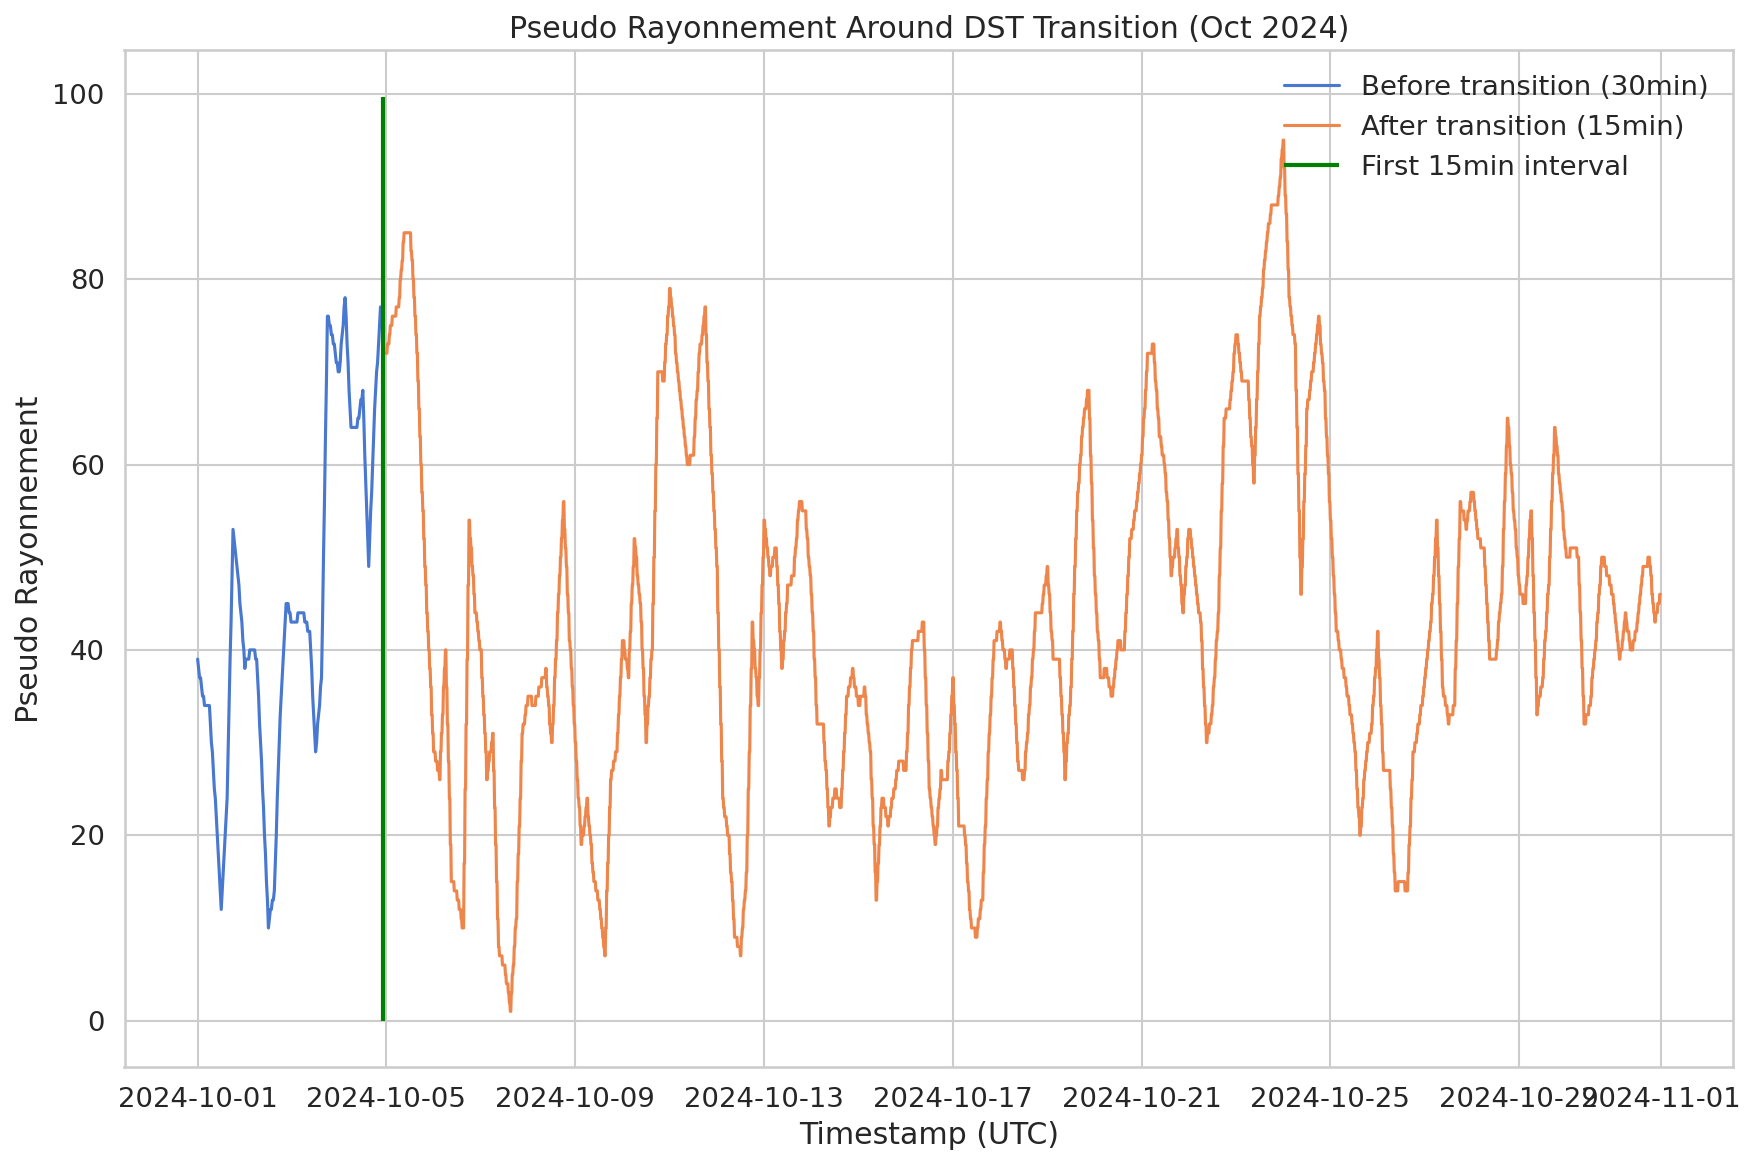

In [23]:
fig, ax = plt.subplots()

right_bound = pl.datetime(2024, 10, 5, 22, 15, 0, time_zone="UTC")
left_bound = pl.datetime(2024, 10, 5, 23, 45, 0, time_zone="UTC")

first_accurance = df_be_2024_10.filter(pl.col("minute_utc").eq(15)).select("timestamp").to_series()[0]

right_range = df_be_2024_10.filter(pl.col("timestamp").ge(first_accurance))
left_range = df_be_2024_10.filter(pl.col("timestamp").lt(first_accurance))


ax.plot(left_range.select("timestamp").to_series(), left_range.select("pseudo_rayonnement").to_series(), label="Before transition (30min)", linestyle="-", linewidth=1.5)
ax.plot(right_range.select("timestamp").to_series(), right_range.select("pseudo_rayonnement").to_series(), label="After transition (15min)", linestyle="-", linewidth=1.5)

ax.vlines(first_accurance, 0, ax.get_ylim()[1], colors="green", linestyles="solid", linewidth=2, label="First 15min interval")

ax.legend(loc="upper right")
ax.set_xlabel("Timestamp (UTC)")
ax.set_ylabel("Pseudo Rayonnement")
ax.set_title("Pseudo Rayonnement Around DST Transition (Oct 2024)")

plt.show()

In [24]:
df_bilan_electrique = df_bilan_electrique.with_columns(
    previous_timestamp=pl.col("timestamp").shift(1),
    time_lag=(pl.col("timestamp") - pl.col("timestamp").shift(1)).dt.total_minutes().cast(pl.Int8)
)

time_related_columns = time_related_columns + ["previous_timestamp", "time_lag"]
df_bilan_electrique.select(time_related_columns)

horodate,mois,datetime,utc_offset,timestamp,year_utc,month_utc,day_utc,hour_utc,minute_utc,previous_timestamp,time_lag
"""2021-03-28T00:00:00+01:00""",3,2021-03-28 00:00:00,"""+01:00""",2021-03-27 23:00:00 UTC,2021,3,27,23,0,null,null
"""2021-03-28T00:30:00+01:00""",3,2021-03-28 00:30:00,"""+01:00""",2021-03-27 23:30:00 UTC,2021,3,27,23,30,2021-03-27 23:00:00 UTC,30
"""2021-03-28T01:00:00+01:00""",3,2021-03-28 01:00:00,"""+01:00""",2021-03-28 00:00:00 UTC,2021,3,28,0,0,2021-03-27 23:30:00 UTC,30
"""2021-03-28T01:30:00+01:00""",3,2021-03-28 01:30:00,"""+01:00""",2021-03-28 00:30:00 UTC,2021,3,28,0,30,2021-03-28 00:00:00 UTC,30
"""2021-03-28T03:00:00+02:00""",3,2021-03-28 03:00:00,"""+02:00""",2021-03-28 01:00:00 UTC,2021,3,28,1,0,2021-03-28 00:30:00 UTC,30
…,…,…,…,…,…,…,…,…,…,…,…
"""2026-03-27T22:45:00+01:00""",3,2026-03-27 22:45:00,"""+01:00""",2026-03-27 21:45:00 UTC,2026,3,27,21,45,2026-03-27 21:30:00 UTC,15
"""2026-03-27T23:00:00+01:00""",3,2026-03-27 23:00:00,"""+01:00""",2026-03-27 22:00:00 UTC,2026,3,27,22,0,2026-03-27 21:45:00 UTC,15
"""2026-03-27T23:15:00+01:00""",3,2026-03-27 23:15:00,"""+01:00""",2026-03-27 22:15:00 UTC,2026,3,27,22,15,2026-03-27 22:00:00 UTC,15
"""2026-03-27T23:30:00+01:00""",3,2026-03-27 23:30:00,"""+01:00""",2026-03-27 22:30:00 UTC,2026,3,27,22,30,2026-03-27 22:15:00 UTC,15


In [25]:
df_bilan_electrique.group_by("time_lag", maintain_order=True).len()

time_lag,len
null,1
30,61774
15,51747


In [26]:
time_lag_30min = df_bilan_electrique.filter(pl.col("time_lag") == 30)
time_lag_15min = df_bilan_electrique.filter(pl.col("time_lag") == 15)

print(f"Proportion of time lags of 30min: {time_lag_30min.height / df_bilan_electrique.height * 100:.2f}")
print(f"Proportion of time lags of 15min: {time_lag_15min.height / df_bilan_electrique.height * 100:.2f}")

Proportion of time lags of 30min: 54.42
Proportion of time lags of 15min: 45.58


In [27]:
time_lag_30min_years = time_lag_30min.select(pl.col("year_utc").unique()).to_numpy().ravel()
time_lag_15min_years = time_lag_15min.select(pl.col("year_utc").unique()).to_numpy().ravel()

print(f"Years with time lag of 30min: {time_lag_30min_years}")
print(f"Years with time lag of 15min: {time_lag_15min_years}")

Years with time lag of 30min: [2021 2022 2023 2024]
Years with time lag of 15min: [2024 2025 2026]


In [28]:
df_bilan_electrique.select(
    pl.col("utc_offset").unique(maintain_order=True).alias("offset"),
    pl.col("utc_offset").unique_counts().alias("count")
)

offset,count
"""+01:00""",50972
"""+02:00""",62550


In [29]:
unique_months_plus_01_00 = df_bilan_electrique.filter(pl.col('utc_offset') == '+01:00').select('month_utc').unique().to_series().to_list()
unique_months_plus_02_00 = df_bilan_electrique.filter(pl.col('utc_offset') == '+02:00').select('month_utc').unique().to_series().to_list()

print(f"Month with UTC offset of 1 hour: {sorted(unique_months_plus_01_00)}")
print(f"Month with UTC offset of 2 hours: {sorted(unique_months_plus_02_00)}")

Month with UTC offset of 1 hour: [1, 2, 3, 10, 11, 12]
Month with UTC offset of 2 hours: [3, 4, 5, 6, 7, 8, 9, 10]


In [30]:
unique_years_plus_02_00 = df_bilan_electrique.filter(pl.col("utc_offset") == "+02:00").select(pl.col("datetime").dt.year()).unique().to_series().to_list()
unique_years_plus_01_00 = df_bilan_electrique.filter(pl.col("utc_offset") == "+01:00").select(pl.col("datetime").dt.year()).unique().to_series().to_list()

print(f"Year with UTC offset of 1 hour: {sorted(unique_years_plus_01_00)}")
print(f"Year with UTC offset of 2 hours: {sorted(unique_years_plus_02_00)}")

Year with UTC offset of 1 hour: [2021, 2022, 2023, 2024, 2025, 2026]
Year with UTC offset of 2 hours: [2021, 2022, 2023, 2024, 2025]


In [31]:
consommation = df_bilan_electrique.select(
    cs.starts_with("consommation")
)
consommation.head()

consommation_totale,consommation_hta,consommation_telerelevee_hta,consommation_telerelevee_btsup,consommation_telerelevee_professionnelle,consommation_telerelevee_residentielle,consommation_profilee_ent_hta,consommation_profilee_ent_bt,consommation_profilee_pro,consommation_profilee_res
40714818826,8860290142,8600953982,1713038870,1625986,99335185,259336160,2258862571,4321336905,23460329167
38829155120,8825914717,8569207381,1696935763,1627819,95592938,256707336,2236973508,4299930516,21672179859
38639093163,8792314924,8540174482,1715576890,1608754,101488575,252140442,2223803664,4278198483,21526101873
38449504487,8742130763,8493093394,1703709606,1584062,105729148,249037369,2242536078,4289976328,21363838502
39200448650,8745196912,8504490036,1744237540,1578094,164181789,240706876,2295073385,4280254010,21969926921


In [32]:
consommation_hta = consommation.select(cs.ends_with("_hta"))
consommation_hta.head()

consommation_hta,consommation_telerelevee_hta,consommation_profilee_ent_hta
8860290142,8600953982,259336160
8825914717,8569207381,256707336
8792314924,8540174482,252140442
8742130763,8493093394,249037369
8745196912,8504490036,240706876


In [33]:
consommation_hta_totale = consommation_hta.select(~cs.by_name("consommation_hta")).fold(lambda s1, s2: s1 + s2).alias("consommation_hta_totale")

consommation_hta_difference =  consommation_hta.get_column("consommation_hta") - consommation_hta_totale
consommation_hta_difference.describe()

statistic,value
"""count""",113522.0000
"""null_count""",0.0000
"""mean""",0.0000
"""std""",0.0000
"""min""",0.0000
"""25%""",0.0000
"""50%""",0.0000
"""75%""",0.0000
"""max""",0.0000


In [34]:
consommation_total = consommation.get_column("consommation_totale")

sum_of_other_consommation_columns = consommation.select(
    ~cs.by_name("consommation_totale", "consommation_hta")
).fold(lambda s1, s2: s1 + s2).alias("consommation_totale_2")


consommation_difference = sum_of_other_consommation_columns - consommation_total
consommation_difference.describe()

statistic,value
"""count""",113522.0000
"""null_count""",0.0000
"""mean""",-0.0010
"""std""",0.6123
"""min""",-2.0000
"""25%""",0.0000
"""50%""",0.0000
"""75%""",0.0000
"""max""",2.0000


In [35]:
consommation_difference.value_counts()

consommation_totale_2,count
0,71852
2,138
-2,157
-1,20727
1,20648


In [36]:
production = df_bilan_electrique.select(
    cs.starts_with("production")
)
production.head()

production_totale,production_telerelevee,production_profilee,production_photovoltaique,production_eolien,production_cogeneration,production_autre,production_profilee_photovoltaique,production_profilee_cogeneration,production_profilee_hydraulique,production_profilee_aut
5416264699,5408322995,7941704,4215751,2377887000,1555242661,1478919287,1508,271370,5557049,2111777
5554492927,5546562387,7930540,4221308,2514920667,1559153267,1476197685,1308,271645,5545810,2111777
5715665204,5707737192,7928012,4219885,2668854333,1562842360,1479748626,3308,272736,5540191,2111777
5887055401,5879104560,7950841,4234888,2835092667,1565597658,1482130188,10645,271370,5557049,2111777
5977829978,5969899792,7930186,4255716,2919970000,1566704042,1486900220,36473,263754,5518182,2111777


In [37]:
production_totale = production.get_column("production_totale")
production_totale_1 = production.select(["production_telerelevee", "production_profilee"]).fold(lambda s1, s2: s1 + s2).alias("production_totale_1")
production_difference_1 = production_totale- production_totale_1
production_difference_1.describe()

statistic,value
"""count""",113522.0000
"""null_count""",0.0000
"""mean""",0.0000
"""std""",0.0000
"""min""",0.0000
"""25%""",0.0000
"""50%""",0.0000
"""75%""",0.0000
"""max""",0.0000


In [38]:
production_totale_2 = production.select(~cs.by_name(["production_totale", "production_telerelevee", "production_profilee"])).fold(lambda s1, s2: s1 + s2).alias("production_totale_2")
production_difference_2 = production_totale - production_totale_2
production_difference_2.describe()

statistic,value
"""count""",113522.0000
"""null_count""",0.0000
"""mean""",-396638898.7199
"""std""",616152223.2008
"""min""",-3148371462.0000
"""25%""",-631228856.0000
"""50%""",-9874698.0000
"""75%""",-3755699.0000
"""max""",-1506247.0000


In [39]:
telerelvee = production.select(["production_telerelevee", "production_photovoltaique", "production_eolien", "production_cogeneration",	"production_autre"])
production_totale_telerelvee = telerelvee.select(~cs.by_name("production_telerelevee")).fold(lambda s1, s2: s1 + s2)
production_telerelvee_difference = production.get_column("production_telerelevee") - production_totale_telerelvee
production_telerelvee_difference.describe()

statistic,value
"""count""",113522.0000
"""null_count""",0.0000
"""mean""",-396638898.7199
"""std""",616152223.2008
"""min""",-3148371462.0000
"""25%""",-631228856.0000
"""50%""",-9874698.0000
"""75%""",-3755699.0000
"""max""",-1506247.0000


In [40]:
production_telerelvee_difference.head()

production_telerelevee
-7941704
-7930540
-7928012
-7950841
-7930186
-7898242
-7914456
-7938187
-8010991
-8079304


In [41]:
(production_telerelvee_difference + production.get_column("production_profilee")).describe()

statistic,value
"""count""",113522.0000
"""null_count""",0.0000
"""mean""",0.0000
"""std""",0.0000
"""min""",0.0000
"""25%""",0.0000
"""50%""",0.0000
"""75%""",0.0000
"""max""",0.0000


In [42]:
df_bilan_electrique.replace_column(df_bilan_electrique.columns.index("production_autre"), df_bilan_electrique.get_column("production_autre") - df_bilan_electrique.get_column("production_profilee"))

horodate,mois,injection_rte,soutirage_rte,soutirage_vers_autres_grd,pertes,consommation_totale,consommation_hta,consommation_telerelevee_hta,consommation_telerelevee_btsup,consommation_telerelevee_professionnelle,consommation_telerelevee_residentielle,consommation_profilee_ent_hta,consommation_profilee_ent_bt,consommation_profilee_pro,consommation_profilee_res,production_totale,production_telerelevee,production_profilee,production_photovoltaique,production_eolien,production_cogeneration,production_autre,production_profilee_photovoltaique,production_profilee_cogeneration,production_profilee_hydraulique,production_profilee_aut,temperature_reelle_lissee,temperature_normale_lissee,pseudo_rayonnement,datetime,utc_offset,timestamp,year_utc,month_utc,day_utc,hour_utc,minute_utc,previous_timestamp,time_lag
"""2021-03-28T00:00:00+01:00""",3,39649341000,756714000,411978603,3182094270,40714818826,8860290142,8600953982,1713038870,1625986,99335185,259336160,2258862571,4321336905,23460329167,5416264699,5408322995,7941704,4215751,2377887000,1555242661,1470977583,1508,271370,5557049,2111777,9.0000,9.4000,86,2021-03-28 00:00:00,"""+01:00""",2021-03-27 23:00:00 UTC,2021,3,27,23,0,null,null
"""2021-03-28T00:30:00+01:00""",3,37536550000,876265000,383639479,3001983328,38829155120,8825914717,8569207381,1696935763,1627819,95592938,256707336,2236973508,4299930516,21672179859,5554492927,5546562387,7930540,4221308,2514920667,1559153267,1468267145,1308,271645,5545810,2111777,9.0000,9.4000,86,2021-03-28 00:30:00,"""+01:00""",2021-03-27 23:30:00 UTC,2021,3,27,23,30,2021-03-27 23:00:00 UTC,30
"""2021-03-28T01:00:00+01:00""",3,37247501000,966056000,367433903,2990583137,38639093163,8792314924,8540174482,1715576890,1608754,101488575,252140442,2223803664,4278198483,21526101873,5715665204,5707737192,7928012,4219885,2668854333,1562842360,1471820614,3308,272736,5540191,2111777,9.0000,9.3000,85,2021-03-28 01:00:00,"""+01:00""",2021-03-28 00:00:00 UTC,2021,3,28,0,0,2021-03-27 23:30:00 UTC,30
"""2021-03-28T01:30:00+01:00""",3,36971406000,1076606000,351078197,2981272717,38449504487,8742130763,8493093394,1703709606,1584062,105729148,249037369,2242536078,4289976328,21363838502,5887055401,5879104560,7950841,4234888,2835092667,1565597658,1474179347,10645,271370,5557049,2111777,8.9000,9.3000,86,2021-03-28 01:30:00,"""+01:00""",2021-03-28 00:30:00 UTC,2021,3,28,0,30,2021-03-28 00:00:00 UTC,30
"""2021-03-28T03:00:00+02:00""",3,37792336000,1164099000,342552756,3063065571,39200448650,8745196912,8504490036,1744237540,1578094,164181789,240706876,2295073385,4280254010,21969926921,5977829978,5969899792,7930186,4255716,2919970000,1566704042,1478970034,36473,263754,5518182,2111777,8.9000,9.3000,86,2021-03-28 03:00:00,"""+02:00""",2021-03-28 01:00:00 UTC,2021,3,28,1,0,2021-03-28 00:30:00 UTC,30
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""2026-03-27T22:45:00+01:00""",3,43239231333,2070908333,418735317,3616204798,44019638414,10802414878,10791622227,4508405848,24977269,451857175,10792651,9333061,4573810745,23648839437,6886255529,6881668911,4586618,3443115,4471961461,918741589,1487522746,487902,71256,1760176,2267284,7.5000,0.0000,63,2026-03-27 22:45:00,"""+01:00""",2026-03-27 21:45:00 UTC,2026,3,27,21,45,2026-03-27 21:30:00 UTC,15
"""2026-03-27T23:00:00+01:00""",3,42906592000,2116126000,427704050,3600727665,43749308494,10672761160,10662169367,4522739006,25746417,454981357,10591793,9111288,4404761827,23659207440,6987274209,6982798525,4475684,3121847,4541620459,908308365,1529747854,378970,71032,1758398,2267284,7.4000,0.0000,62,2026-03-27 23:00:00,"""+01:00""",2026-03-27 22:00:00 UTC,2026,3,27,22,0,2026-03-27 21:45:00 UTC,15
"""2026-03-27T23:15:00+01:00""",3,42194297000,2182893666,418295467,3545241934,43170113312,10597112811,10586448994,4426708068,25470703,450359352,10663817,9173245,4367361480,23293927654,7122247379,7117902055,4345324,2890001,4648983441,907576365,1558452248,248610,71032,1758398,2267284,7.4000,0.0000,62,2026-03-27 23:15:00,"""+01:00"""

In [43]:
production = df_bilan_electrique.select(
    cs.starts_with("production")
)
production.head()

production_totale,production_telerelevee,production_profilee,production_photovoltaique,production_eolien,production_cogeneration,production_autre,production_profilee_photovoltaique,production_profilee_cogeneration,production_profilee_hydraulique,production_profilee_aut
5416264699,5408322995,7941704,4215751,2377887000,1555242661,1470977583,1508,271370,5557049,2111777
5554492927,5546562387,7930540,4221308,2514920667,1559153267,1468267145,1308,271645,5545810,2111777
5715665204,5707737192,7928012,4219885,2668854333,1562842360,1471820614,3308,272736,5540191,2111777
5887055401,5879104560,7950841,4234888,2835092667,1565597658,1474179347,10645,271370,5557049,2111777
5977829978,5969899792,7930186,4255716,2919970000,1566704042,1478970034,36473,263754,5518182,2111777


In [44]:
production_totale_2 = production.select(~cs.by_name(["production_totale", "production_telerelevee", "production_profilee"])).fold(lambda s1, s2: s1 + s2).alias("production_totale_2")
production_difference_2 = production_totale - production_totale_2
production_difference_2.describe()

statistic,value
"""count""",113522.0000
"""null_count""",0.0000
"""mean""",0.0000
"""std""",0.0000
"""min""",0.0000
"""25%""",0.0000
"""50%""",0.0000
"""75%""",0.0000
"""max""",0.0000


In [45]:
injection_rte = df_bilan_electrique.get_column("injection_rte")
soutirage_rte = df_bilan_electrique.get_column("soutirage_rte")
soutirage_vers_autres_grd = df_bilan_electrique.get_column("soutirage_vers_autres_grd")
pertes = df_bilan_electrique.get_column("pertes")

In [46]:
bilan_energetique = (injection_rte + production_totale) - (consommation_total + soutirage_rte + soutirage_vers_autres_grd + pertes)
bilan_energetique.describe()

statistic,value
"""count""",113522.0000
"""null_count""",0.0000
"""mean""",0.2513
"""std""",0.4338
"""min""",0.0000
"""25%""",0.0000
"""50%""",0.0000
"""75%""",1.0000
"""max""",1.0000


In [47]:
time_related_columns.remove("horodate")
time_related_columns.remove("mois")

columns_to_drop = [
    "horodate", "mois", "consommation_hta", "datetime", "utc_offset", "previous_timestamp", 
]

df_bilan_electrique = df_bilan_electrique.drop(columns_to_drop, strict=False)
df_bilan_electrique

injection_rte,soutirage_rte,soutirage_vers_autres_grd,pertes,consommation_totale,consommation_telerelevee_hta,consommation_telerelevee_btsup,consommation_telerelevee_professionnelle,consommation_telerelevee_residentielle,consommation_profilee_ent_hta,consommation_profilee_ent_bt,consommation_profilee_pro,consommation_profilee_res,production_totale,production_telerelevee,production_profilee,production_photovoltaique,production_eolien,production_cogeneration,production_autre,production_profilee_photovoltaique,production_profilee_cogeneration,production_profilee_hydraulique,production_profilee_aut,temperature_reelle_lissee,temperature_normale_lissee,pseudo_rayonnement,timestamp,year_utc,month_utc,day_utc,hour_utc,minute_utc,time_lag
39649341000,756714000,411978603,3182094270,40714818826,8600953982,1713038870,1625986,99335185,259336160,2258862571,4321336905,23460329167,5416264699,5408322995,7941704,4215751,2377887000,1555242661,1470977583,1508,271370,5557049,2111777,9.0000,9.4000,86,2021-03-27 23:00:00 UTC,2021,3,27,23,0,null
37536550000,876265000,383639479,3001983328,38829155120,8569207381,1696935763,1627819,95592938,256707336,2236973508,4299930516,21672179859,5554492927,5546562387,7930540,4221308,2514920667,1559153267,1468267145,1308,271645,5545810,2111777,9.0000,9.4000,86,2021-03-27 23:30:00 UTC,2021,3,27,23,30,30
37247501000,966056000,367433903,2990583137,38639093163,8540174482,1715576890,1608754,101488575,252140442,2223803664,4278198483,21526101873,5715665204,5707737192,7928012,4219885,2668854333,1562842360,1471820614,3308,272736,5540191,2111777,9.0000,9.3000,85,2021-03-28 00:00:00 UTC,2021,3,28,0,0,30
36971406000,1076606000,351078197,2981272717,38449504487,8493093394,1703709606,1584062,105729148,249037369,2242536078,4289976328,21363838502,5887055401,5879104560,7950841,4234888,2835092667,1565597658,1474179347,10645,271370,5557049,2111777,8.9000,9.3000,86,2021-03-28 00:30:00 UTC,2021,3,28,0,30,30
37792336000,1164099000,342552756,3063065571,39200448650,8504490036,1744237540,1578094,164181789,240706876,2295073385,4280254010,21969926921,5977829978,5969899792,7930186,4255716,2919970000,1566704042,1478970034,36473,263754,5518182,2111777,8.9000,9.3000,86,2021-03-28 01:00:00 UTC,2021,3,28,1,0,30
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
43239231333,2070908333,418735317,3616204798,44019638414,10791622227,4508405848,24977269,451857175,10792651,9333061,4573810745,23648839437,6886255529,6881668911,4586618,3443115,4471961461,918741589,1487522746,487902,71256,1760176,2267284,7.5000,0.0000,63,2026-03-27 21:45:00 UTC,2026,3,27,21,45,15
42906592000,2116126000,427704050,3600727665,43749308494,10662169367,4522739006,25746417,454981357,10591793,9111288,4404761827,23659207440,6987274209,6982798525,4475684,3121847,4541620459,908308365,1529747854,378970,71032,1758398,2267284,7.4000,0.0000,62,2026-03-27 22:00:00 UTC,2026,3,27,22,0,15
42194297000,2182893666,418295467,3545241934,43170113312,10586448994,4426708068,25470703,450359352,10663817,9173245,4367361480,23293927654,7122247379,7117902055,4345324,2890001,4648983441,907576365,1558452248,248610,71032,1758398,2267284,7.4000,0.0000,62,2026-03-27 22:15:00 UTC,2026,3,27,22,15,15
42752734333,2148285000,433346800,3604594664,43683652917,10554720978,4386380134,25425072,460407264,10312451,8935057,4305251742,23932220219,7117145048,7112892048,4253000,2611239,4714043773,906331991,1489905045,154882,70658,1760176,2267284,7.4000,0.0000,62,2026-03-27 22:30:00 UTC,2026,3,27,22,30,15


In [48]:
energy_price_dfs = []

for year in range(2021, 2027):
    df = pl.read_csv(RAW_DATA_PATH / f"energy_prices_{year}.csv", ignore_errors=True, batch_size=5_000)
    energy_price_dfs.append(df)

In [49]:
for year, energy_price_df in enumerate(energy_price_dfs, start=2021):
    print(f"Energy Prices Dataset {year}".center(100,"-"), "\n")
    print(f"Number of samples: {energy_price_df.height} _ Number of variables: {energy_price_df.width}\n")
    pprint.pprint(energy_price_df.schema, indent=4)
    print()
    print(f"Number of missing values: {energy_price_df.null_count()}")

-------------------------------------Energy Prices Dataset 2021------------------------------------- 

Number of samples: 8760 _ Number of variables: 6

Schema([   ('MTU (CET/CEST)', String),
           ('Area', String),
           ('Sequence', String),
           ('Day-ahead Price (EUR/MWh)', Float64),
           ('Intraday Period (CET/CEST)', String),
           ('Intraday Price (EUR/MWh)', String)])

Number of missing values: shape: (1, 6)
┌────────────────┬──────┬──────────┬───────────────────────────┬────────────────────────────┬──────────────────────────┐
│ MTU (CET/CEST) ┆ Area ┆ Sequence ┆ Day-ahead Price (EUR/MWh) ┆ Intraday Period (CET/CEST) ┆ Intraday Price (EUR/MWh) │
╞════════════════╪══════╪══════════╪═══════════════════════════╪════════════════════════════╪══════════════════════════╡
│ 0              ┆ 0    ┆ 0        ┆ 0                         ┆ 0                          ┆ 0                        │
└────────────────┴──────┴──────────┴───────────────────────────┴─────

In [50]:
energy_price_df_2021 = energy_price_dfs[0]
energy_price_df_2021.describe()

statistic,MTU (CET/CEST),Area,Sequence,Day-ahead Price (EUR/MWh),Intraday Period (CET/CEST),Intraday Price (EUR/MWh)
"""count""","""8760""","""8760""","""8760""",8760.0000,"""8760""","""8760"""
"""null_count""","""0""","""0""","""0""",0.0000,"""0""","""0"""
"""mean""",null,null,null,109.1714,null,null
"""std""",null,null,null,84.3161,null,null
"""min""","""01/01/2021 00:00:00 - 01/01/2021 01:00:00""","""BZN|FR""","""Without Sequence""",-66.1800,"""""",""""""
"""25%""",null,null,null,56.0000,null,null
"""50%""",null,null,null,78.4500,null,null
"""75%""",null,null,null,140.5300,null,null
"""max""","""31/12/2021 23:00:00 - 01/01/2022 00:00:00""","""BZN|FR""","""Without Sequence""",620.0000,"""""",""""""


In [51]:
intraday_period_2021 = energy_price_df_2021.get_column("Intraday Period (CET/CEST)")
intraday_period_2021.unique()

Intraday Period (CET/CEST)
""""""


In [52]:
intraday_price = energy_price_df_2021.get_column("Intraday Price (EUR/MWh)")
intraday_period_2021.unique()

Intraday Period (CET/CEST)
""""""


In [53]:
area = energy_price_df_2021.get_column("Area")
area.unique()

Area
"""BZN|FR"""


In [54]:
sequence = energy_price_df_2021.get_column("Sequence")
sequence.unique()

Sequence
"""Without Sequence"""


In [55]:
for year, energy_price_df in enumerate(energy_price_dfs[1:], start=2022):
    print(f"Energy Prices Dataset {year}".center(100,"-"), "\n")
    print(f"Unique Values For Each Column")
    print(energy_price_df.get_column("Intraday Period (CET/CEST)").unique(), "\n")
    print(energy_price_df.get_column("Intraday Price (EUR/MWh)").unique(), "\n")
    print(energy_price_df.get_column("Area").unique(), "\n")
    print(energy_price_df.get_column("Sequence").unique(), "\n")

-------------------------------------Energy Prices Dataset 2022------------------------------------- 

Unique Values For Each Column
shape: (1,)
Series: 'Intraday Period (CET/CEST)' [str]
[
	""
] 

shape: (1,)
Series: 'Intraday Price (EUR/MWh)' [str]
[
	""
] 

shape: (1,)
Series: 'Area' [str]
[
	"BZN|FR"
] 

shape: (1,)
Series: 'Sequence' [str]
[
	"Without Sequence"
] 

-------------------------------------Energy Prices Dataset 2023------------------------------------- 

Unique Values For Each Column
shape: (1,)
Series: 'Intraday Period (CET/CEST)' [str]
[
	""
] 

shape: (1,)
Series: 'Intraday Price (EUR/MWh)' [str]
[
	""
] 

shape: (1,)
Series: 'Area' [str]
[
	"BZN|FR"
] 

shape: (1,)
Series: 'Sequence' [str]
[
	"Without Sequence"
] 

-------------------------------------Energy Prices Dataset 2024------------------------------------- 

Unique Values For Each Column
shape: (1,)
Series: 'Intraday Period (CET/CEST)' [str]
[
	""
] 

shape: (1,)
Series: 'Intraday Price (EUR/MWh)' [str]
[
	

In [56]:
columns_to_drop = ["Intraday Price (EUR/MWh)", "Intraday Period (CET/CEST)"]
for i in range(energy_price_dfs.__len__()):
    energy_price_df = energy_price_dfs[i]
    energy_price_df = energy_price_df.drop(columns_to_drop)
    energy_price_dfs[i] = energy_price_df

In [57]:
for year, df in enumerate(energy_price_dfs, 2021):
    print(f"Energy Prices Dataset {year}".center(100,"-"), "\n")
    pprint.pprint(df.schema)

-------------------------------------Energy Prices Dataset 2021------------------------------------- 

Schema([('MTU (CET/CEST)', String),
        ('Area', String),
        ('Sequence', String),
        ('Day-ahead Price (EUR/MWh)', Float64)])
-------------------------------------Energy Prices Dataset 2022------------------------------------- 

Schema([('MTU (CET/CEST)', String),
        ('Area', String),
        ('Sequence', String),
        ('Day-ahead Price (EUR/MWh)', Float64)])
-------------------------------------Energy Prices Dataset 2023------------------------------------- 

Schema([('MTU (CET/CEST)', String),
        ('Area', String),
        ('Sequence', String),
        ('Day-ahead Price (EUR/MWh)', Float64)])
-------------------------------------Energy Prices Dataset 2024------------------------------------- 

Schema([('MTU (CET/CEST)', String),
        ('Area', String),
        ('Sequence', String),
        ('Day-ahead Price (EUR/MWh)', Float64)])
------------------------

In [58]:
ep_df_2021 = energy_price_dfs[0]
ep_df_2021

MTU (CET/CEST),Area,Sequence,Day-ahead Price (EUR/MWh)
"""01/01/2021 00:00:00 - 01/01/2021 01:00:00""","""BZN|FR""","""Without Sequence""",50.8700
"""01/01/2021 01:00:00 - 01/01/2021 02:00:00""","""BZN|FR""","""Without Sequence""",48.1900
"""01/01/2021 02:00:00 - 01/01/2021 03:00:00""","""BZN|FR""","""Without Sequence""",44.6800
"""01/01/2021 03:00:00 - 01/01/2021 04:00:00""","""BZN|FR""","""Without Sequence""",42.9200
"""01/01/2021 04:00:00 - 01/01/2021 05:00:00""","""BZN|FR""","""Without Sequence""",40.3900
…,…,…,…
"""31/12/2021 19:00:00 - 31/12/2021 20:00:00""","""BZN|FR""","""Without Sequence""",175.9400
"""31/12/2021 20:00:00 - 31/12/2021 21:00:00""","""BZN|FR""","""Without Sequence""",157.9200
"""31/12/2021 21:00:00 - 31/12/2021 22:00:00""","""BZN|FR""","""Without Sequence""",175.1200
"""31/12/2021 22:00:00 - 31/12/2021 23:00:00""","""BZN|FR""","""Without Sequence""",140.3800


In [59]:
time_format_pattern = r"\d{2}/\d{2}/\d{4}\s\d{2}:\d{2}:\d{2}\s-\s\d{2}/\d{2}/\d{4}\s\d{2}:\d{2}:\d{2}"
ep_df_2021 = ep_df_2021.with_columns(
    match_pattern=pl.col("MTU (CET/CEST)").str.contains(time_format_pattern)
)

ep_df_2021.null_count()

MTU (CET/CEST),Area,Sequence,Day-ahead Price (EUR/MWh),match_pattern
0,0,0,0,0


In [60]:
ep_df_2021_match_not_founded = ep_df_2021.filter(~pl.col("match_pattern"))
ep_df_2021_match_not_founded.get_column("MTU (CET/CEST)")

MTU (CET/CEST)
"""28/03/2021 01:00:00 (CET) - 28/03/2021 03:00:00 (C…"
"""28/03/2021 03:00:00 (CEST) - 28/03/2021 04:00:00"""
"""31/10/2021 02:00:00 (CEST) - 31/10/2021 02:00:00 (…"
"""31/10/2021 02:00:00 (CET) - 31/10/2021 03:00:00"""


In [61]:
ep_df_2021_match_not_founded.get_column("MTU (CET/CEST)")[0]

'28/03/2021 01:00:00 (CET) - 28/03/2021 03:00:00 (CEST)'

In [62]:
ep_df_2021_match_not_founded.get_column("MTU (CET/CEST)")[2]

'31/10/2021 02:00:00 (CEST) - 31/10/2021 02:00:00 (CET)'

In [63]:
ep_df_2021 = ep_df_2021.with_columns(
    datetime=pl.col("MTU (CET/CEST)").str.extract(r"(\d{2}/\d{2}/\d{4}\s\d{2}:\d{2}:\d{2})", 0).str.to_datetime(format="%d/%m/%Y %H:%M:%S"),
    timezone_offset=pl.col("MTU (CET/CEST)").str.extract(r"\(([A-Z]+)\)", 0)
)

ep_df_2021.null_count()

MTU (CET/CEST),Area,Sequence,Day-ahead Price (EUR/MWh),match_pattern,datetime,timezone_offset
0,0,0,0,0,0,8754


In [64]:
ep_df_2021 = ep_df_2021.sort("datetime")

In [65]:
ep_df_2021.head()

MTU (CET/CEST),Area,Sequence,Day-ahead Price (EUR/MWh),match_pattern,datetime,timezone_offset
"""01/01/2021 00:00:00 - 01/01/2021 01:00:00""","""BZN|FR""","""Without Sequence""",50.8700,true,2021-01-01 00:00:00,null
"""01/01/2021 01:00:00 - 01/01/2021 02:00:00""","""BZN|FR""","""Without Sequence""",48.1900,true,2021-01-01 01:00:00,null
"""01/01/2021 02:00:00 - 01/01/2021 03:00:00""","""BZN|FR""","""Without Sequence""",44.6800,true,2021-01-01 02:00:00,null
"""01/01/2021 03:00:00 - 01/01/2021 04:00:00""","""BZN|FR""","""Without Sequence""",42.9200,true,2021-01-01 03:00:00,null
"""01/01/2021 04:00:00 - 01/01/2021 05:00:00""","""BZN|FR""","""Without Sequence""",40.3900,true,2021-01-01 04:00:00,null


In [66]:
ep_df_2021.tail()

MTU (CET/CEST),Area,Sequence,Day-ahead Price (EUR/MWh),match_pattern,datetime,timezone_offset
"""31/12/2021 19:00:00 - 31/12/2021 20:00:00""","""BZN|FR""","""Without Sequence""",175.9400,true,2021-12-31 19:00:00,null
"""31/12/2021 20:00:00 - 31/12/2021 21:00:00""","""BZN|FR""","""Without Sequence""",157.9200,true,2021-12-31 20:00:00,null
"""31/12/2021 21:00:00 - 31/12/2021 22:00:00""","""BZN|FR""","""Without Sequence""",175.1200,true,2021-12-31 21:00:00,null
"""31/12/2021 22:00:00 - 31/12/2021 23:00:00""","""BZN|FR""","""Without Sequence""",140.3800,true,2021-12-31 22:00:00,null
"""31/12/2021 23:00:00 - 01/01/2022 00:00:00""","""BZN|FR""","""Without Sequence""",127.8100,true,2021-12-31 23:00:00,null


In [67]:
ep_df_2021.get_column("timezone_offset").unique()

timezone_offset
"""(CET)"""
"""(CEST)"""
null


In [68]:
ep_df_2021 = ep_df_2021.replace_column(ep_df_2021.columns.index("timezone_offset"), ep_df_2021.get_column("timezone_offset").fill_null(strategy="backward"))
ep_df_2021 = ep_df_2021.replace_column(ep_df_2021.columns.index("timezone_offset"), ep_df_2021.get_column("timezone_offset").fill_null(strategy="forward"))
ep_df_2021

MTU (CET/CEST),Area,Sequence,Day-ahead Price (EUR/MWh),match_pattern,datetime,timezone_offset
"""01/01/2021 00:00:00 - 01/01/2021 01:00:00""","""BZN|FR""","""Without Sequence""",50.8700,true,2021-01-01 00:00:00,"""(CET)"""
"""01/01/2021 01:00:00 - 01/01/2021 02:00:00""","""BZN|FR""","""Without Sequence""",48.1900,true,2021-01-01 01:00:00,"""(CET)"""
"""01/01/2021 02:00:00 - 01/01/2021 03:00:00""","""BZN|FR""","""Without Sequence""",44.6800,true,2021-01-01 02:00:00,"""(CET)"""
"""01/01/2021 03:00:00 - 01/01/2021 04:00:00""","""BZN|FR""","""Without Sequence""",42.9200,true,2021-01-01 03:00:00,"""(CET)"""
"""01/01/2021 04:00:00 - 01/01/2021 05:00:00""","""BZN|FR""","""Without Sequence""",40.3900,true,2021-01-01 04:00:00,"""(CET)"""
…,…,…,…,…,…,…
"""31/12/2021 19:00:00 - 31/12/2021 20:00:00""","""BZN|FR""","""Without Sequence""",175.9400,true,2021-12-31 19:00:00,"""(CET)"""
"""31/12/2021 20:00:00 - 31/12/2021 21:00:00""","""BZN|FR""","""Without Sequence""",157.9200,true,2021-12-31 20:00:00,"""(CET)"""
"""31/12/2021 21:00:00 - 31/12/2021 22:00:00""","""BZN|FR""","""Without Sequence""",175.1200,true,2021-12-31 21:00:00,"""(CET)"""
"""31/12/2021 22:00:00 - 31/12/2021 23:00:00""","""BZN|FR""","""Without Sequence""",140.3800,true,2021-12-31 22:00:00,"""(CET)"""


In [69]:
ep_df_2021.null_count()

MTU (CET/CEST),Area,Sequence,Day-ahead Price (EUR/MWh),match_pattern,datetime,timezone_offset
0,0,0,0,0,0,0


In [70]:
ep_df_2021 = ep_df_2021.with_columns(
    utc_offset=pl.when(pl.col("timezone_offset") == "(CEST)")
        .then(pl.lit("+02:00"))
        .when(pl.col("timezone_offset") == "(CET)")
        .then(pl.lit("+01:00"))
)
ep_df_2021

MTU (CET/CEST),Area,Sequence,Day-ahead Price (EUR/MWh),match_pattern,datetime,timezone_offset,utc_offset
"""01/01/2021 00:00:00 - 01/01/2021 01:00:00""","""BZN|FR""","""Without Sequence""",50.8700,true,2021-01-01 00:00:00,"""(CET)""","""+01:00"""
"""01/01/2021 01:00:00 - 01/01/2021 02:00:00""","""BZN|FR""","""Without Sequence""",48.1900,true,2021-01-01 01:00:00,"""(CET)""","""+01:00"""
"""01/01/2021 02:00:00 - 01/01/2021 03:00:00""","""BZN|FR""","""Without Sequence""",44.6800,true,2021-01-01 02:00:00,"""(CET)""","""+01:00"""
"""01/01/2021 03:00:00 - 01/01/2021 04:00:00""","""BZN|FR""","""Without Sequence""",42.9200,true,2021-01-01 03:00:00,"""(CET)""","""+01:00"""
"""01/01/2021 04:00:00 - 01/01/2021 05:00:00""","""BZN|FR""","""Without Sequence""",40.3900,true,2021-01-01 04:00:00,"""(CET)""","""+01:00"""
…,…,…,…,…,…,…,…
"""31/12/2021 19:00:00 - 31/12/2021 20:00:00""","""BZN|FR""","""Without Sequence""",175.9400,true,2021-12-31 19:00:00,"""(CET)""","""+01:00"""
"""31/12/2021 20:00:00 - 31/12/2021 21:00:00""","""BZN|FR""","""Without Sequence""",157.9200,true,2021-12-31 20:00:00,"""(CET)""","""+01:00"""
"""31/12/2021 21:00:00 - 31/12/2021 22:00:00""","""BZN|FR""","""Without Sequence""",175.1200,true,2021-12-31 21:00:00,"""(CET)""","""+01:00"""
"""31/12/2021 22:00:00 - 31/12/2021 23:00:00""","""BZN|FR""","""Without Sequence""",140.3800,true,2021-12-31 22:00:00,"""(CET)""","""+01:00"""


In [71]:
ep_df_2021.null_count()

MTU (CET/CEST),Area,Sequence,Day-ahead Price (EUR/MWh),match_pattern,datetime,timezone_offset,utc_offset
0,0,0,0,0,0,0,0


In [72]:
ep_df_2021 = ep_df_2021.with_columns(
    timestamp=pl.concat_str(
        pl.col("datetime").dt.strftime("%d/%m/%Y %H:%M:%S"),
        pl.col("utc_offset")
    ).str.to_datetime(format="%d/%m/%Y %H:%M:%S%z")
)
ep_df_2021

MTU (CET/CEST),Area,Sequence,Day-ahead Price (EUR/MWh),match_pattern,datetime,timezone_offset,utc_offset,timestamp
"""01/01/2021 00:00:00 - 01/01/2021 01:00:00""","""BZN|FR""","""Without Sequence""",50.8700,true,2021-01-01 00:00:00,"""(CET)""","""+01:00""",2020-12-31 23:00:00 UTC
"""01/01/2021 01:00:00 - 01/01/2021 02:00:00""","""BZN|FR""","""Without Sequence""",48.1900,true,2021-01-01 01:00:00,"""(CET)""","""+01:00""",2021-01-01 00:00:00 UTC
"""01/01/2021 02:00:00 - 01/01/2021 03:00:00""","""BZN|FR""","""Without Sequence""",44.6800,true,2021-01-01 02:00:00,"""(CET)""","""+01:00""",2021-01-01 01:00:00 UTC
"""01/01/2021 03:00:00 - 01/01/2021 04:00:00""","""BZN|FR""","""Without Sequence""",42.9200,true,2021-01-01 03:00:00,"""(CET)""","""+01:00""",2021-01-01 02:00:00 UTC
"""01/01/2021 04:00:00 - 01/01/2021 05:00:00""","""BZN|FR""","""Without Sequence""",40.3900,true,2021-01-01 04:00:00,"""(CET)""","""+01:00""",2021-01-01 03:00:00 UTC
…,…,…,…,…,…,…,…,…
"""31/12/2021 19:00:00 - 31/12/2021 20:00:00""","""BZN|FR""","""Without Sequence""",175.9400,true,2021-12-31 19:00:00,"""(CET)""","""+01:00""",2021-12-31 18:00:00 UTC
"""31/12/2021 20:00:00 - 31/12/2021 21:00:00""","""BZN|FR""","""Without Sequence""",157.9200,true,2021-12-31 20:00:00,"""(CET)""","""+01:00""",2021-12-31 19:00:00 UTC
"""31/12/2021 21:00:00 - 31/12/2021 22:00:00""","""BZN|FR""","""Without Sequence""",175.1200,true,2021-12-31 21:00:00,"""(CET)""","""+01:00""",2021-12-31 20:00:00 UTC
"""31/12/2021 22:00:00 - 31/12/2021 23:00:00""","""BZN|FR""","""Without Sequence""",140.3800,true,2021-12-31 22:00:00,"""(CET)""","""+01:00""",2021-12-31 21:00:00 UTC


In [73]:
ep_df_2021.null_count()

MTU (CET/CEST),Area,Sequence,Day-ahead Price (EUR/MWh),match_pattern,datetime,timezone_offset,utc_offset,timestamp
0,0,0,0,0,0,0,0,0


In [74]:
columns_to_drop = ["MTU (CET/CEST)", "datetime", "timezone_offset", "utc_offset", "match_pattern"]
ep_df_2021 = ep_df_2021.drop(columns_to_drop)
ep_df_2021

Area,Sequence,Day-ahead Price (EUR/MWh),timestamp
"""BZN|FR""","""Without Sequence""",50.8700,2020-12-31 23:00:00 UTC
"""BZN|FR""","""Without Sequence""",48.1900,2021-01-01 00:00:00 UTC
"""BZN|FR""","""Without Sequence""",44.6800,2021-01-01 01:00:00 UTC
"""BZN|FR""","""Without Sequence""",42.9200,2021-01-01 02:00:00 UTC
"""BZN|FR""","""Without Sequence""",40.3900,2021-01-01 03:00:00 UTC
…,…,…,…
"""BZN|FR""","""Without Sequence""",175.9400,2021-12-31 18:00:00 UTC
"""BZN|FR""","""Without Sequence""",157.9200,2021-12-31 19:00:00 UTC
"""BZN|FR""","""Without Sequence""",175.1200,2021-12-31 20:00:00 UTC
"""BZN|FR""","""Without Sequence""",140.3800,2021-12-31 21:00:00 UTC


In [75]:
energy_price_dfs[0] = ep_df_2021

In [76]:

for (year, ep_df) in enumerate(energy_price_dfs[1:], 2022):
    print(f"Energy Prices Dataset {year}".center(100,"-"), "\n")
    
    print(f"Regular Pattern Mathing")
    ep_df = ep_df.with_columns(
        match_pattern=pl.col("MTU (CET/CEST)").str.contains(time_format_pattern)
    )
    print(ep_df.null_count())
    
    ep_df_match_not_founded = ep_df.filter(~pl.col("match_pattern"))
    print(ep_df_match_not_founded.get_column("MTU (CET/CEST)"))
    
    ep_df = ep_df.with_columns(
        datetime=pl.col("MTU (CET/CEST)").str.extract(r"(\d{2}/\d{2}/\d{4}\s\d{2}:\d{2}:\d{2})", 0).str.to_datetime(format="%d/%m/%Y %H:%M:%S"),
        timezone_offset=pl.col("MTU (CET/CEST)").str.extract(r"\(([A-Z]+)\)", 0)
    )
    ep_df = ep_df.sort("datetime")
    print("Dateset After Adding Columns (datetime, timezone)")
    print(ep_df.head(), "\n")
    
    print("Unique values for the timezone_offset")
    print(ep_df.get_column("timezone_offset").unique(), "\n")
    
    ep_df = ep_df.replace_column(ep_df.columns.index("timezone_offset"), ep_df.get_column("timezone_offset").fill_null(strategy="backward"))
    ep_df = ep_df.replace_column(ep_df.columns.index("timezone_offset"), ep_df.get_column("timezone_offset").fill_null(strategy="forward"))
    
    print("Null Values After Filling Them")
    print(ep_df.null_count(), "\n")
    print(ep_df, "\n")
    
    print("Feature Engineering Columns")
    ep_df = ep_df.with_columns(
    utc_offset=pl.when(pl.col("timezone_offset") == "(CEST)")
        .then(pl.lit("+02:00"))
        .when(pl.col("timezone_offset") == "(CET)")
        .then(pl.lit("+01:00"))
    )
    ep_df = ep_df.with_columns(
    timestamp=pl.concat_str(
        pl.col("datetime").dt.strftime("%d/%m/%Y %H:%M:%S"),
        pl.col("utc_offset")
    ).str.to_datetime(format="%d/%m/%Y %H:%M:%S%z")
    )
    print(ep_df, "\n")
    
    print("Duplicate Values In Tiemetamp Column")
    print(ep_df.get_column("timestamp").is_duplicated().sum())
    if ep_df.get_column("timestamp").is_duplicated().sum():
        ep_df = ep_df.filter(pl.col("timestamp").is_unique())
    
    print("Final Dataset After Preprocessing")
    ep_df = ep_df.drop(columns_to_drop)
    print(ep_df, "\n")
    
    energy_price_dfs[year - 2021] = ep_df

-------------------------------------Energy Prices Dataset 2022------------------------------------- 

Regular Pattern Mathing
shape: (1, 5)
┌────────────────┬──────┬──────────┬───────────────────────────┬───────────────┐
│ MTU (CET/CEST) ┆ Area ┆ Sequence ┆ Day-ahead Price (EUR/MWh) ┆ match_pattern │
╞════════════════╪══════╪══════════╪═══════════════════════════╪═══════════════╡
│ 0              ┆ 0    ┆ 0        ┆ 0                         ┆ 0             │
└────────────────┴──────┴──────────┴───────────────────────────┴───────────────┘
shape: (4,)
Series: 'MTU (CET/CEST)' [str]
[
	"27/03/2022 01:00:00 (CET) - 27/03/2022 03:00:00 (C…
	"27/03/2022 03:00:00 (CEST) - 27/03/2022 04:00:00"
	"30/10/2022 02:00:00 (CEST) - 30/10/2022 02:00:00 (…
	"30/10/2022 02:00:00 (CET) - 30/10/2022 03:00:00"
]
Dateset After Adding Columns (datetime, timezone)
shape: (5, 7)
┌───────────────────────────────────────────┬────────┬──────────────────┬───────────────────────────┬───────────────┬───────────────

In [77]:
for i in range(5):
    ep_df_current_year = energy_price_dfs[i]
    ep_df_next_year = energy_price_dfs[i+1]
    leaked_rows = ep_df_next_year.filter(pl.col("timestamp").dt.year() == (2021 + i))
    if not leaked_rows.is_empty():
        ep_df_current_year.vstack(leaked_rows, in_place=True)
        ep_df_next_year = ep_df_next_year.filter(pl.col("timestamp").dt.year() != (2021 + i))
        energy_price_dfs[i] = ep_df_current_year
        energy_price_dfs[i+1] = ep_df_next_year

In [78]:
for ep_df in energy_price_dfs:
    print(f"Energy Prices Dataset {year}".center(100,"-"), "\n")
    print(ep_df.head(1))
    print(ep_df.tail(1))

-------------------------------------Energy Prices Dataset 2026------------------------------------- 

shape: (1, 4)
┌────────┬──────────────────┬───────────────────────────┬─────────────────────────┐
│ Area   ┆ Sequence         ┆ Day-ahead Price (EUR/MWh) ┆ timestamp               │
╞════════╪══════════════════╪═══════════════════════════╪═════════════════════════╡
│ BZN|FR ┆ Without Sequence ┆ 50.8700                   ┆ 2020-12-31 23:00:00 UTC │
└────────┴──────────────────┴───────────────────────────┴─────────────────────────┘
shape: (1, 4)
┌────────┬──────────────────┬───────────────────────────┬─────────────────────────┐
│ Area   ┆ Sequence         ┆ Day-ahead Price (EUR/MWh) ┆ timestamp               │
╞════════╪══════════════════╪═══════════════════════════╪═════════════════════════╡
│ BZN|FR ┆ Without Sequence ┆ 89.0600                   ┆ 2021-12-31 23:00:00 UTC │
└────────┴──────────────────┴───────────────────────────┴─────────────────────────┘
-----------------------------

In [79]:
for year, ep_df in enumerate(energy_price_dfs, 2021):
    print(f"The Time Lag Used In Year {year}".center(100,"-"))
    ep_df = ep_df.with_columns(
        lag=ep_df.get_column("timestamp") - ep_df.shift(1).get_column("timestamp")
    )
    
    print(ep_df.get_column("lag").unique())

-----------------------------------The Time Lag Used In Year 2021-----------------------------------
shape: (2,)
Series: 'lag' [duration[μs]]
[
	null
	1h
]
-----------------------------------The Time Lag Used In Year 2022-----------------------------------
shape: (2,)
Series: 'lag' [duration[μs]]
[
	null
	1h
]
-----------------------------------The Time Lag Used In Year 2023-----------------------------------
shape: (2,)
Series: 'lag' [duration[μs]]
[
	null
	1h
]
-----------------------------------The Time Lag Used In Year 2024-----------------------------------
shape: (3,)
Series: 'lag' [duration[μs]]
[
	null
	15m
	1h
]
-----------------------------------The Time Lag Used In Year 2025-----------------------------------
shape: (4,)
Series: 'lag' [duration[μs]]
[
	null
	15m
	1d 15m
	47d 1h 15m
]
-----------------------------------The Time Lag Used In Year 2026-----------------------------------
shape: (2,)
Series: 'lag' [duration[μs]]
[
	null
	15m
]


In [80]:
ep_df_2024 = energy_price_dfs[3]
ep_df_2024

Area,Sequence,Day-ahead Price (EUR/MWh),timestamp
"""BZN|FR""","""Without Sequence""",0.0100,2024-01-01 00:00:00 UTC
"""BZN|FR""","""Without Sequence""",0.0000,2024-01-01 01:00:00 UTC
"""BZN|FR""","""Without Sequence""",-0.0100,2024-01-01 02:00:00 UTC
"""BZN|FR""","""Without Sequence""",-0.0300,2024-01-01 03:00:00 UTC
"""BZN|FR""","""Without Sequence""",-0.0200,2024-01-01 04:00:00 UTC
…,…,…,…
"""BZN|FR""","""Without Sequence""",60.1800,2024-12-31 22:00:00 UTC
"""BZN|FR""","""Without Sequence""",12.3600,2024-12-31 23:00:00 UTC
"""BZN|FR""","""Without Sequence""",12.3600,2024-12-31 23:15:00 UTC
"""BZN|FR""","""Without Sequence""",12.3600,2024-12-31 23:30:00 UTC


In [81]:
ep_df_2024 = ep_df_2024.with_columns(
        lag=ep_df_2024.get_column("timestamp") - ep_df_2024.shift(1).get_column("timestamp")
    )
ep_df_2024

Area,Sequence,Day-ahead Price (EUR/MWh),timestamp,lag
"""BZN|FR""","""Without Sequence""",0.0100,2024-01-01 00:00:00 UTC,null
"""BZN|FR""","""Without Sequence""",0.0000,2024-01-01 01:00:00 UTC,1h
"""BZN|FR""","""Without Sequence""",-0.0100,2024-01-01 02:00:00 UTC,1h
"""BZN|FR""","""Without Sequence""",-0.0300,2024-01-01 03:00:00 UTC,1h
"""BZN|FR""","""Without Sequence""",-0.0200,2024-01-01 04:00:00 UTC,1h
…,…,…,…,…
"""BZN|FR""","""Without Sequence""",60.1800,2024-12-31 22:00:00 UTC,1h
"""BZN|FR""","""Without Sequence""",12.3600,2024-12-31 23:00:00 UTC,1h
"""BZN|FR""","""Without Sequence""",12.3600,2024-12-31 23:15:00 UTC,15m
"""BZN|FR""","""Without Sequence""",12.3600,2024-12-31 23:30:00 UTC,15m


/home/abdelaziz/Desktop/enedis_pipeline/data_analytics/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


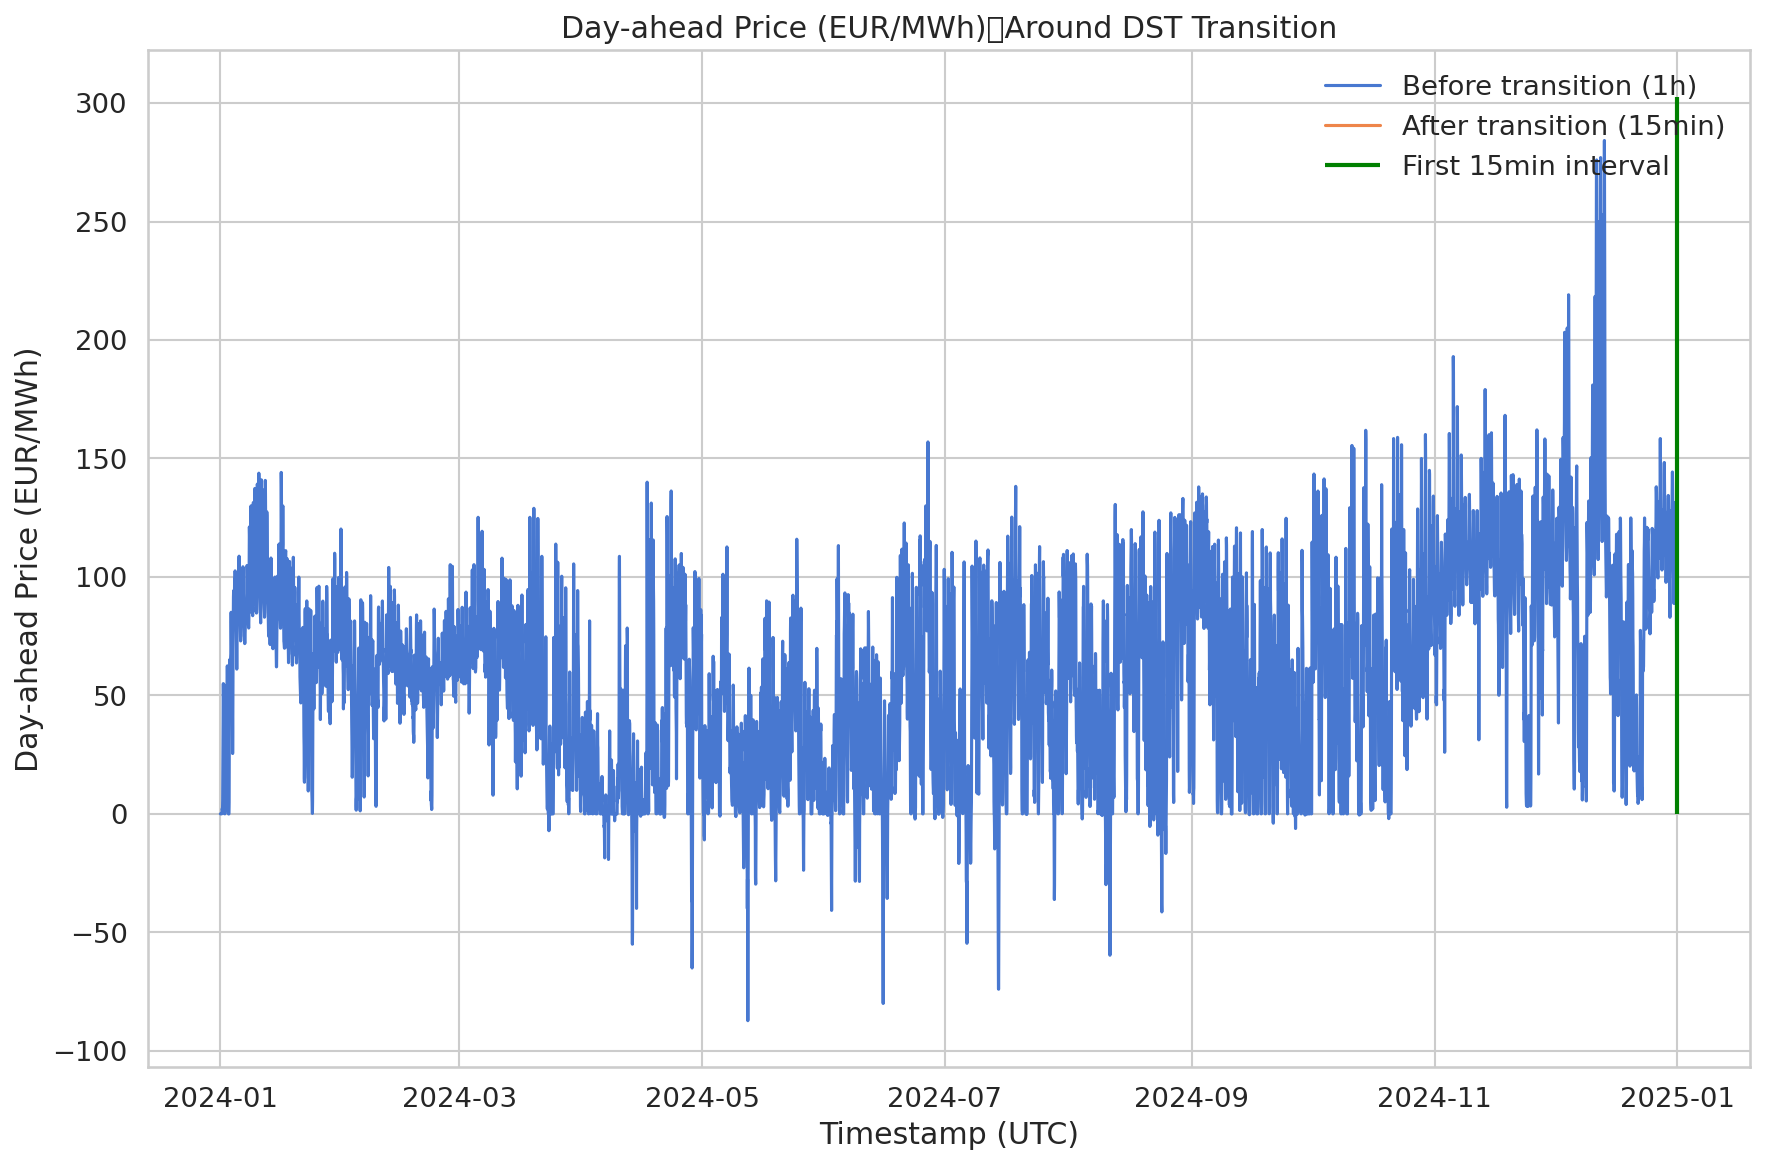

In [82]:
fig, ax = plt.subplots()

first_accurance = ep_df_2024.filter(pl.col("timestamp").dt.minute().eq(15)).select("timestamp").to_series()[0]

right_range = ep_df_2024.filter(pl.col("timestamp").ge(first_accurance))
left_range = ep_df_2024.filter(pl.col("timestamp").lt(first_accurance))


ax.plot(left_range.select("timestamp").to_series(), left_range.select("Day-ahead Price (EUR/MWh)").to_series(), label="Before transition (1h)", linestyle="-", linewidth=1.5)
ax.plot(right_range.select("timestamp").to_series(), right_range.select("Day-ahead Price (EUR/MWh)").to_series(), label="After transition (15min)", linestyle="-", linewidth=1.5)

ax.vlines(first_accurance, 0, ax.get_ylim()[1], colors="green", linestyles="solid", linewidth=2, label="First 15min interval")

ax.legend(loc="upper right")
ax.set_xlabel("Timestamp (UTC)")
ax.set_ylabel("Day-ahead Price (EUR/MWh)")
ax.set_title("Day-ahead Price (EUR/MWh)	Around DST Transition")

plt.show()

In [83]:
ep_df_2025 = energy_price_dfs[4].with_columns(
    previous_timestamp=energy_price_dfs[4].shift(1).get_column("timestamp"),
    lag=energy_price_dfs[4].get_column("timestamp") - energy_price_dfs[4].shift(1).get_column("timestamp")
)
ep_df_2025.group_by("lag").len()

lag,len
null,1
15m,30425
47d 1h 15m,1
1d 15m,1


In [84]:
ep_df_2025.filter(pl.col("lag").eq(pl.duration(days=47, hours=1, minutes=15)))

Area,Sequence,Day-ahead Price (EUR/MWh),timestamp,previous_timestamp,lag
"""BZN|FR""","""Without Sequence""",73.8000,2025-11-16 23:00:00 UTC,2025-09-30 21:45:00 UTC,47d 1h 15m


In [85]:
ep_df_2025.filter(pl.col("lag").eq(pl.duration(days=1, minutes=15)))

Area,Sequence,Day-ahead Price (EUR/MWh),timestamp,previous_timestamp,lag
"""BZN|FR""","""Without Sequence""",89.0000,2025-11-19 23:00:00 UTC,2025-11-18 22:45:00 UTC,1d 15m


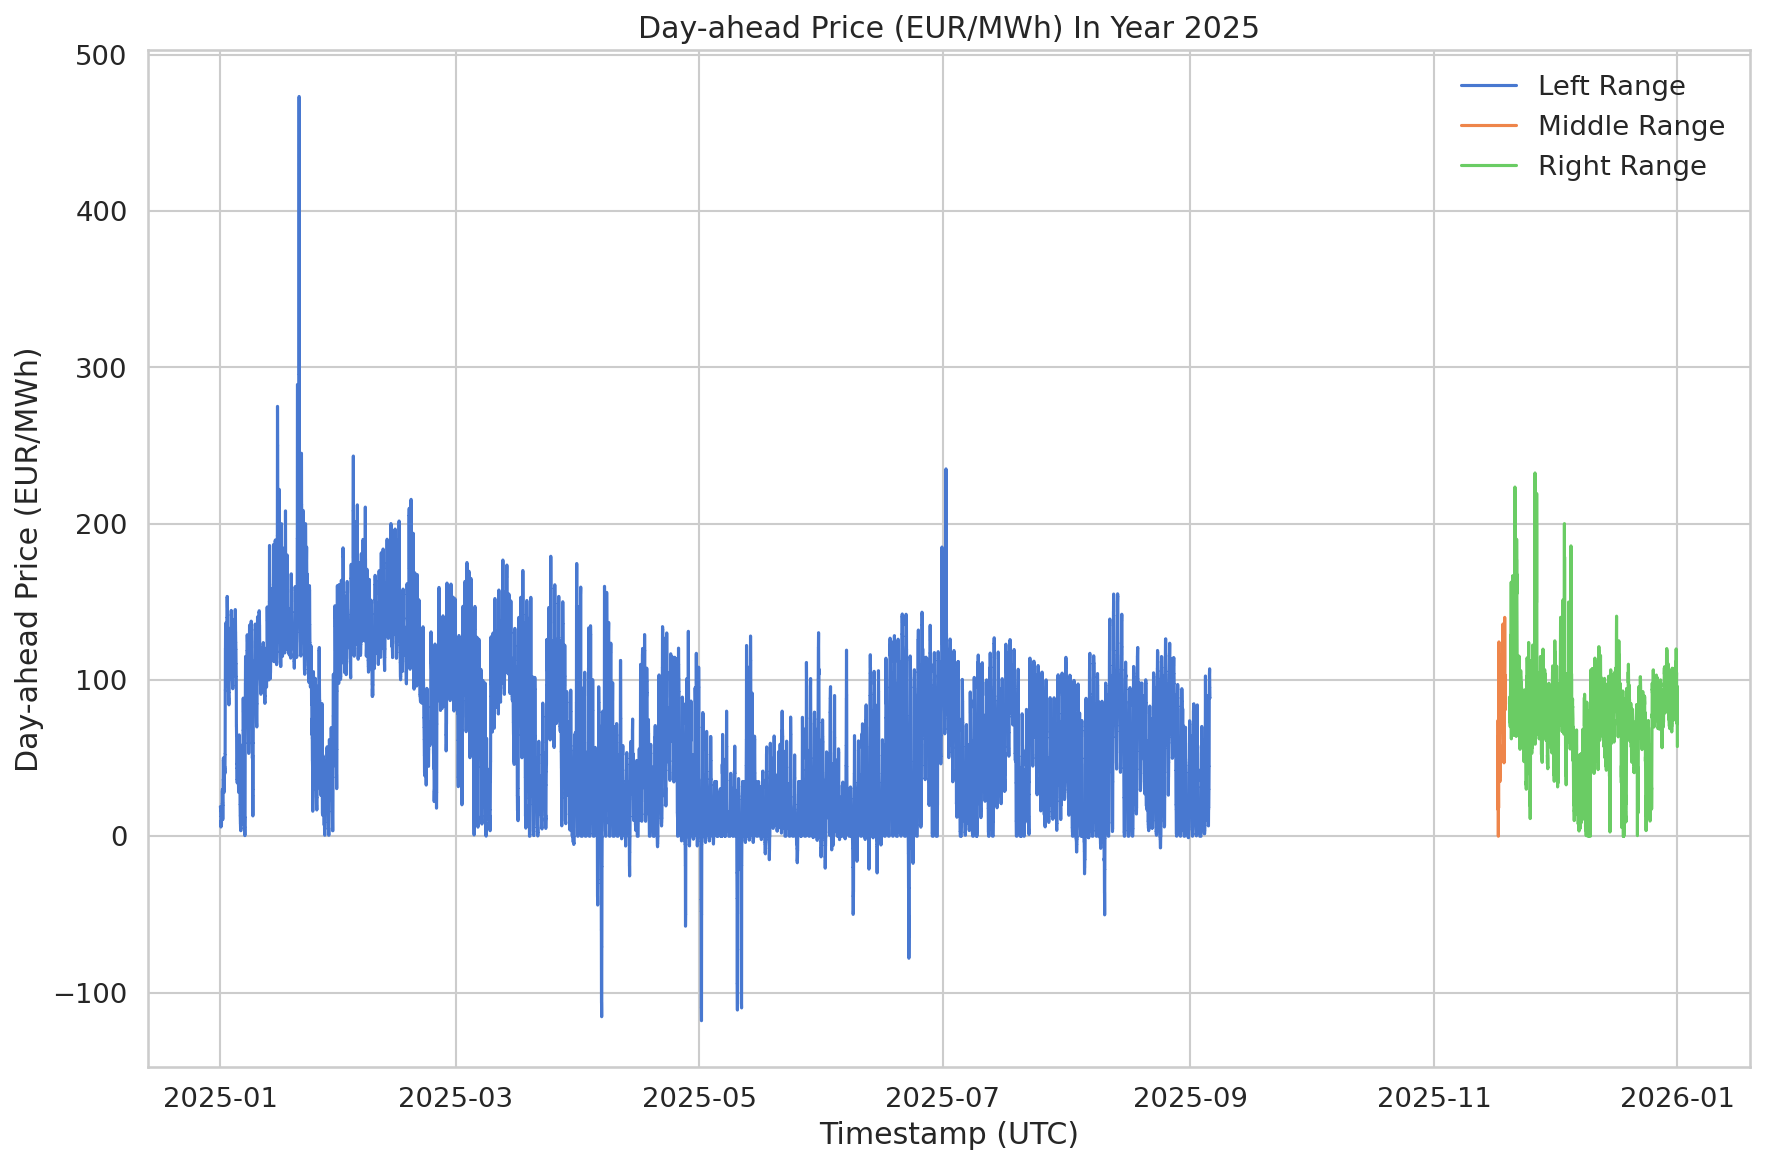

In [86]:
fig, ax = plt.subplots()

fleft_bound = pl.datetime(2025, 9, 5, 21, 45, 0, time_zone="UTC")
fright_bound = pl.datetime(2025, 11, 16, 23, 0, 0, time_zone="UTC")

sright_bound = pl.datetime(2025, 11, 19, 23, 0, 0, time_zone="UTC")
sleft_bound = pl.datetime(2025, 11, 18, 22, 45, 0, time_zone="UTC")

left_range = ep_df_2025.filter(pl.col("timestamp").le(fleft_bound))
middle_range = ep_df_2025.filter(pl.col("timestamp").ge(fright_bound), pl.col("timestamp").le(sleft_bound))
right_range = ep_df_2025.filter(pl.col("timestamp").ge(sright_bound))

start = pl.datetime(2025, 1, 1, 0, 0, 0, time_zone="UTC")
end = pl.datetime(2025, 12, 31, 23, 45, 0, time_zone="UTC")

ax.plot(left_range.get_column("timestamp"), left_range.get_column("Day-ahead Price (EUR/MWh)"), label="Left Range")
ax.plot(middle_range.get_column("timestamp"), middle_range.get_column("Day-ahead Price (EUR/MWh)"), label="Middle Range")
ax.plot(right_range.get_column("timestamp"), right_range.get_column("Day-ahead Price (EUR/MWh)"), label="Right Range")

ax.legend(loc="upper right")
ax.set_xlabel("Timestamp (UTC)")
ax.set_ylabel("Day-ahead Price (EUR/MWh)")
ax.set_title("Day-ahead Price (EUR/MWh) In Year 2025")

plt.tight_layout()
plt.show()

In [87]:
bilan_energetique_dfs = [df_bilan_electrique.filter(pl.col("year_utc").eq(year)) for year in range(2021, 2027)]
bilan_energetique_dfs.__len__()

6

In [88]:
joined_dfs = []
for i in range(6):
    print(f"Joining Datasets For Year: {i+2021}")
    ep_df = energy_price_dfs[i]
    be_df = bilan_energetique_dfs[i]
    joined_df = be_df.join(ep_df, "timestamp", "left")
    print(f"Rows Conserved: {joined_df.height == be_df.height}", "\n")
    joined_dfs.append(joined_df)
    

Joining Datasets For Year: 2021
Rows Conserved: True 

Joining Datasets For Year: 2022
Rows Conserved: True 

Joining Datasets For Year: 2023
Rows Conserved: True 

Joining Datasets For Year: 2024
Rows Conserved: True 

Joining Datasets For Year: 2025
Rows Conserved: True 

Joining Datasets For Year: 2026
Rows Conserved: True 



In [89]:
for year, df in enumerate(joined_dfs, 2021):
    print(f"Joined Dataset For Year: {year}".center(100,"-"), "\n")
    print("Null Values Count:")
    print(df.null_count())
    print(f"Dataset Shape: {df.shape}")

-----------------------------------Joined Dataset For Year: 2021------------------------------------ 

Null Values Count:
shape: (1, 37)
┌───────────────┬───────────────┬───────────────────────────┬────────┬─────────────────────┬──────────────────────────────┬────────────────────────────────┬──────────────────────────────────────────┬────────────────────────────────────────┬───────────────────────────────┬──────────────────────────────┬───────────────────────────┬───────────────────────────┬───────────────────┬────────────────────────┬─────────────────────┬───────────────────────────┬───────────────────┬─────────────────────────┬──────────────────┬────────────────────────────────────┬──────────────────────────────────┬─────────────────────────────────┬─────────────────────────┬───────────────────────────┬────────────────────────────┬────────────────────┬───────────┬──────────┬───────────┬─────────┬──────────┬────────────┬──────────┬──────┬──────────┬───────────────────────────┐
│ injec

In [90]:
for year, df in enumerate(joined_dfs, 2021):
    if year >= 2025:
        continue
    joined_dfs[year - 2021] = joined_dfs[year - 2021].fill_null(strategy="forward")
    print(joined_dfs[year - 2021].null_count())
    print(joined_dfs[year-2021])

shape: (1, 37)
┌───────────────┬───────────────┬───────────────────────────┬────────┬─────────────────────┬──────────────────────────────┬────────────────────────────────┬──────────────────────────────────────────┬────────────────────────────────────────┬───────────────────────────────┬──────────────────────────────┬───────────────────────────┬───────────────────────────┬───────────────────┬────────────────────────┬─────────────────────┬───────────────────────────┬───────────────────┬─────────────────────────┬──────────────────┬────────────────────────────────────┬──────────────────────────────────┬─────────────────────────────────┬─────────────────────────┬───────────────────────────┬────────────────────────────┬────────────────────┬───────────┬──────────┬───────────┬─────────┬──────────┬────────────┬──────────┬──────┬──────────┬───────────────────────────┐
│ injection_rte ┆ soutirage_rte ┆ soutirage_vers_autres_grd ┆ pertes ┆ consommation_totale ┆ consommation_telerelevee_hta ┆ conso

In [91]:
for year, df in enumerate(joined_dfs, 2021):
    joined_dfs[year - 2021].write_parquet(PROCESSED_DATA_PATH / f"enedis_dataset_year_{year}.parquet")